In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Import the splitting tool
from sklearn.model_selection import train_test_split


##Data Cleanning

In [213]:
#read the file
df=pd.read_csv('/content/garments_worker_productivity.csv')
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [214]:
df.shape

(1197, 15)

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [216]:
#Number of Duplicate rows
df.duplicated().sum()

np.int64(0)

In [217]:
#Checking the missing values in each column before removing the duplicates
df.isnull().sum()

,0
date,0
quarter,0
department,0
day,0
team,0
targeted_productivity,0
smv,0
wip,506
over_time,0
incentive,0


In [218]:
# Check which departments have missing WIP
print(df.groupby('department')['wip'].apply(lambda x: x.isnull().sum()))

department
finishing     249
finishing     257
sweing          0
Name: wip, dtype: int64


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

In [220]:
##Remove the space in finishing
# Remove the invisible spaces at the end of the words
df['department'] = df['department'].str.strip()

# Now check the unique values again
print(df['department'].unique())


['sweing' 'finishing']


In [221]:
#Fix Department Names (Typo & Spaces)
df['department'] = df['department'].str.strip().replace('sweing', 'sewing')

In [222]:
#Round up workers to nearest whole number
# Logic: You cannot have a fraction of a person for labor optimization
df['no_of_workers'] = np.ceil(df['no_of_workers']).astype(int)

In [223]:
#  Again Check which departments have missing WIP
print(df.groupby('department')['wip'].apply(lambda x: x.isnull().sum()))

department
finishing    506
sewing         0
Name: wip, dtype: int64


In [224]:
# Identify rows where 'no_of_workers' has a decimal part (not a whole number)
non_integer_workers = df[df['no_of_workers'] % 1 != 0]

# Count the number of such rows
num_rows = len(non_integer_workers)

print(f"Number of rows with decimal workers: {num_rows}")

# Display the unique decimal values found
print("Unique decimal values in the column:")
print(non_integer_workers['no_of_workers'].unique())

Number of rows with decimal workers: 0
Unique decimal values in the column:
[]


In [225]:
# Count the number of rows where actual_productivity is greater than 1
count = (df['actual_productivity'] > 1).sum()

print(f"Count of rows with productivity > 1: {count}")

Count of rows with productivity > 1: 37


In [226]:
#Cap Actual Productivity at 1.0
df['actual_productivity'] = df['actual_productivity'].clip(upper=1.0)


In [227]:
#Handle Quarter 5 (Optional: renaming to Quarter4 for consistency)
df['quarter'] = df['quarter'].replace('Quarter5', 'Quarter4')

In [228]:
#Convert Date to Datetime objects
df['date'] = pd.to_datetime(df['date'])
# Conver Int to object for team variable
df['team'] = df['team'].astype(object)
# Convert over time and incentive to the float
df[['over_time', 'incentive']] = df[['over_time', 'incentive']].astype(float)
# Conver _no_of_workers to the int
df['no_of_workers'] = df['no_of_workers'].astype(int)

In [229]:
# Dropping the team column from both sets before splitting
df.drop(columns=['team'], inplace=True, errors='ignore')

print("Team ID has been removed. The model will now focus purely on resource metrics.")

Team ID has been removed. The model will now focus purely on resource metrics.


In [230]:
df.drop(columns=['date'], inplace=True, errors='ignore')

##Split data set into trainnig and testing


In [231]:
# Perform a random split (80% train, 20% test)
# random_state ensures reproducibility
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

# Check number of rows in each part
print("train_data:", train_data.shape[0])
print("test_data:", test_data.shape[0])

train_data: 957
test_data: 240


In [232]:
train_data.isnull().sum()

,0
quarter,0
department,0
day,0
targeted_productivity,0
smv,0
wip,415
over_time,0
incentive,0
idle_time,0
idle_men,0


In [233]:

#Select numerical columns
num_cols = train_data.select_dtypes(include=['float64', 'int64']).columns

# Drop the specific column from the Index object
num_cols = num_cols.drop('actual_productivity')
train_numeric = train_data[num_cols]
test_numeric = test_data[num_cols]

In [234]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice = IterativeImputer(max_iter=10, random_state=42)

# Fit only on train
train_imputed = pd.DataFrame(
    mice.fit_transform(train_numeric),
    columns=num_cols,
    index=train_numeric.index
)

# Transform test (DO NOT FIT AGAIN)
test_imputed = pd.DataFrame(
    mice.transform(test_numeric),
    columns=num_cols,
    index=test_numeric.index
)

In [235]:
train_data['wip'] = train_imputed['wip']
test_data['wip'] = test_imputed['wip']

In [236]:
train_data

,quarter,department,day,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
1189,Quarter2,sewing,Wednesday,0.70,30.48,914.000000,6840.0,30.0,0.0,0,1,57,0.700505
575,Quarter1,finishing,Monday,0.75,3.94,1185.814897,2280.0,0.0,0.0,0,0,19,0.504596
76,Quarter1,finishing,Monday,0.75,2.90,1184.984148,960.0,0.0,0.0,0,0,8,0.763375
731,Quarter2,finishing,Thursday,0.70,4.15,1185.512804,1800.0,0.0,0.0,0,0,15,1.000000
138,Quarter2,sewing,Thursday,0.80,11.61,548.000000,15120.0,63.0,0.0,0,0,32,0.800107
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,Quarter1,finishing,Tuesday,0.70,4.60,1186.494503,3360.0,0.0,0.0,0,0,8,0.354444
1095,Quarter1,finishing,Saturday,0.50,2.90,1184.984148,960.0,0.0,0.0,0,0,8,0.797500
1130,Quarter2,finishing,Monday,0.60,3.94,1184.573542,0.0,2880.0,0.0,0,0,12,0.864343
860,Quarter3,sewing,Thursday,0.75,30.10,444.000000,0.0,0.0,5.0,20,1,59,0.611141


In [237]:
X_train = train_data.drop(columns=['actual_productivity'])
y_train = train_data['actual_productivity']
X_test = test_data.drop(columns=['actual_productivity'])
y_test = test_data['actual_productivity']
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

X_train shape: (957, 12), y_train shape: (957,)


In [238]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 957 entries, 1189 to 1126
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   quarter                957 non-null    object 
 1   department             957 non-null    object 
 2   day                    957 non-null    object 
 3   targeted_productivity  957 non-null    float64
 4   smv                    957 non-null    float64
 5   wip                    957 non-null    float64
 6   over_time              957 non-null    float64
 7   incentive              957 non-null    float64
 8   idle_time              957 non-null    float64
 9   idle_men               957 non-null    int64  
 10  no_of_style_change     957 non-null    int64  
 11  no_of_workers          957 non-null    int64  
dtypes: float64(6), int64(3), object(3)
memory usage: 97.2+ KB


In [239]:
# Drop 'team' from both sets
X_train = X_train.drop(columns=['team'], errors='ignore')
X_test = X_test.drop(columns=['team'], errors='ignore')

##FAMD

In [240]:
!pip install prince

--- Silhouette Scores Calculation (12 Components) ---
For k = 2, Silhouette Score: 0.2283
For k = 3, Silhouette Score: 0.2363
For k = 4, Silhouette Score: 0.2315
For k = 5, Silhouette Score: 0.2410
For k = 6, Silhouette Score: 0.2288
For k = 7, Silhouette Score: 0.1945


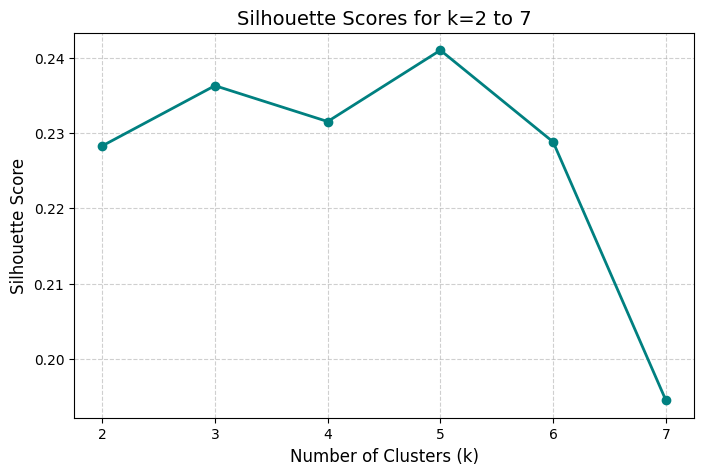

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prince import FAMD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure categorical columns in X_train are string type for consistency before fitting FAMD
categorical_cols_train = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols_train:
    X_train[col] = X_train[col].astype(str)

# 1. Initialize FAMD for 12 components
# Prince handles mixed data (numerical and categorical) automatically
famd = FAMD(
    n_components=12,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit and transform the training data to get 12 principal components
X_famd = famd.fit_transform(X_train)

# 2. Iterate for k = 2 to 7 and calculate Silhouette scores
k_range = range(2, 8)
sil_scores = []

print("--- Silhouette Scores Calculation (12 Components) ---")
for k in k_range:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    # Fit and predict clusters on the FAMD components
    cluster_labels = kmeans.fit_predict(X_famd)

    # Calculate Silhouette score
    score = silhouette_score(X_famd, cluster_labels)
    sil_scores.append(score)
    print(f"For k = {k}, Silhouette Score: {score:.4f}")

# 3. Visualization of Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, sil_scores, marker='o', linestyle='-', color='teal', linewidth=2)
plt.title('Silhouette Scores for k=2 to 7', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

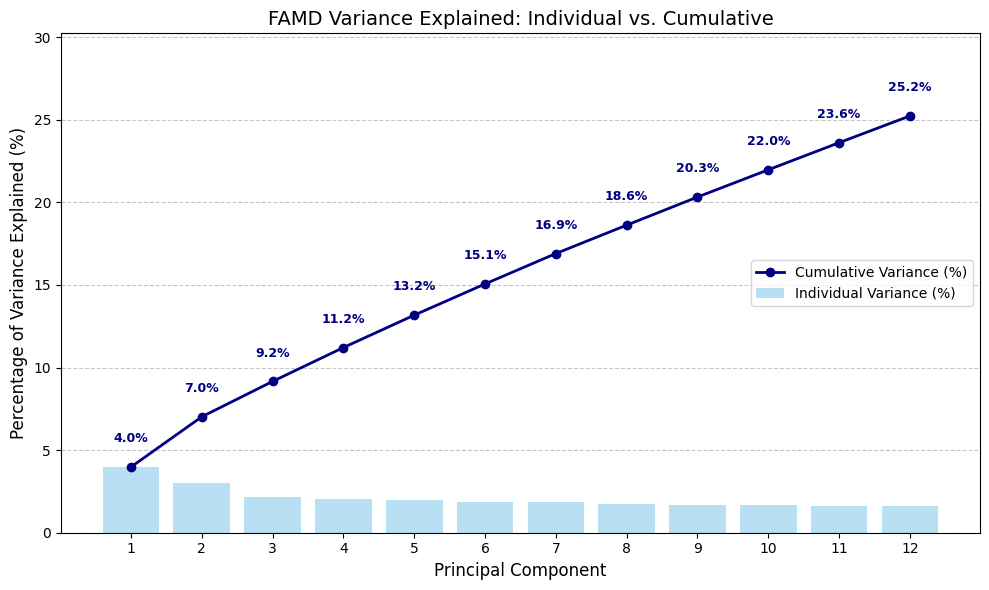

In [242]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the variance data from your fitted FAMD model
# eigenvalues_summary returns a DataFrame with '% of variance' and '% of variance (cumulative)'
variance_df = famd.eigenvalues_summary

# Convert percentage strings to floats (handling '%' sign if present)
ind_var = variance_df['% of variance'].str.replace('%', '').astype(float)
cum_var = variance_df['% of variance (cumulative)'].str.replace('%', '').astype(float)
components = range(1, len(ind_var) + 1)

# 2. Create the Plot
plt.figure(figsize=(10, 6))

# Plot Individual Variance as bars (Kept as is)
plt.bar(components, ind_var, alpha=0.6, color='skyblue', label='Individual Variance (%)')

# CHANGED: Plot Cumulative Variance as a standard line plot
plt.plot(components, cum_var, color='navy', marker='o', linewidth=2, label='Cumulative Variance (%)')

# 3. Formatting
plt.title('FAMD Variance Explained: Individual vs. Cumulative', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Percentage of Variance Explained (%)', fontsize=12)
plt.xticks(components)
plt.ylim(0, max(cum_var) + 5)  # Add some space at the top
plt.legend(loc='center right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add text labels on top of the line for clarity
for i, val in enumerate(cum_var):
    plt.text(list(components)[i], val + 1.5, f'{val:.1f}%', ha='center', fontsize=9, color='navy', fontweight='bold')

plt.tight_layout()
plt.show()

--- Silhouette Scores (k=2) ---
Training Set: 0.1974
Testing Set:  0.1794


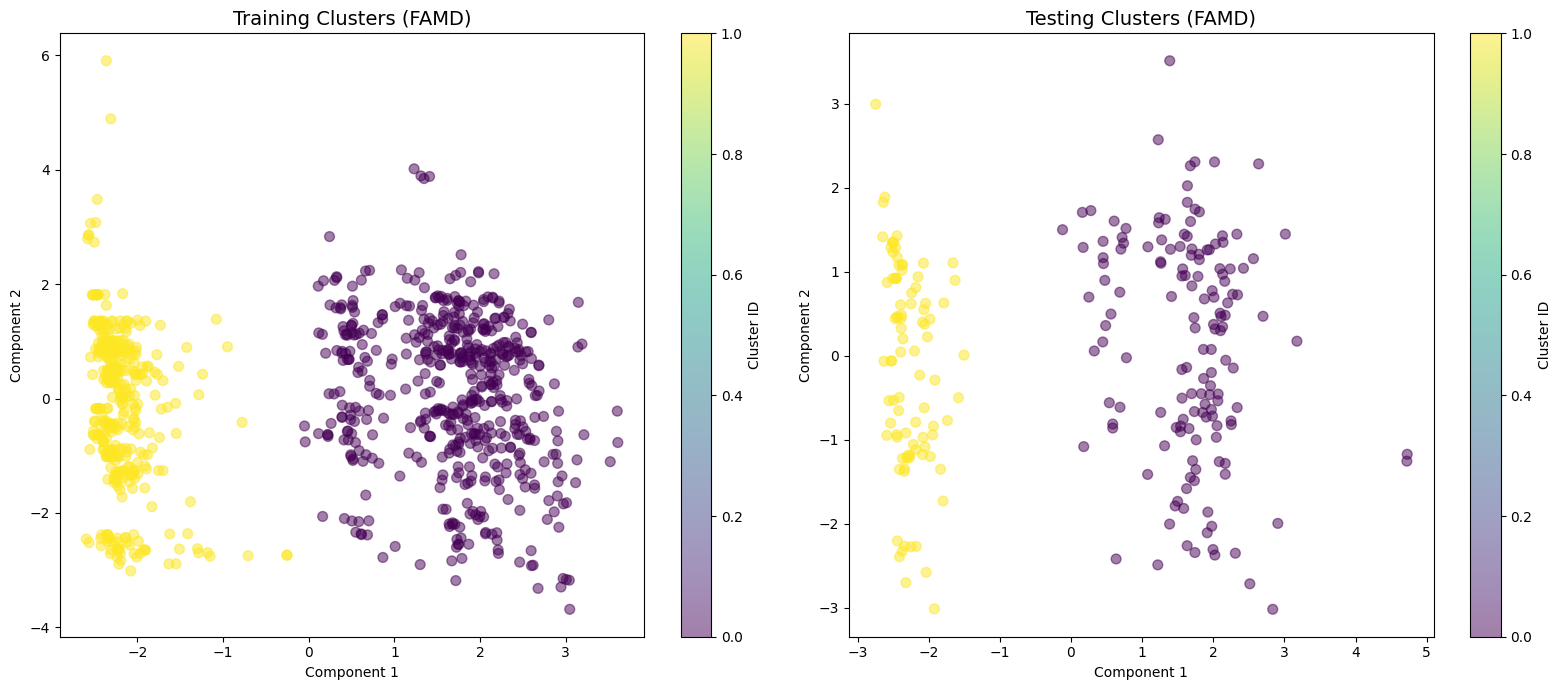

In [243]:
import pandas as pd
import matplotlib.pyplot as plt
from prince import FAMD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ensure categorical columns in X_train are string type for consistency before fitting FAMD
categorical_cols_train = X_train.select_dtypes(include=['object']).columns
for col in categorical_cols_train:
    X_train[col] = X_train[col].astype(str)

# Explicitly convert integer numerical columns to float to avoid misinterpretation by FAMD
# This ensures 'idle_men', 'no_of_style_change', 'no_of_workers' are treated numerically
for col in ['idle_men', 'no_of_style_change', 'no_of_workers']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(float)
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(float)

# 1. Initialize FAMD for 12 components
# Prince handles mixed data (numerical and categorical) automatically
famd = FAMD(
    n_components=12,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

# Fit on training data only to avoid data leakage
famd = famd.fit(X_train)

X_train_famd = famd.transform(X_train)

# Ensure categorical columns in X_test are string type for consistency
categorical_cols_test = X_test.select_dtypes(include=['object']).columns
for col in categorical_cols_test:
    X_test[col] = X_test[col].astype(str)

# Set handle_unknown='ignore' for the internal OneHotEncoder before transforming X_test
# This prevents errors if X_test contains categories not seen in X_train
# (Only applies if a categorical encoder is used by FAMD, which it does for object/category dtypes)
# This specific line might not be directly applicable as FAMD handles its internal encoders.
# However, the explicit type conversion above should prevent 'idle_men' from being treated as categorical.

# Transform both Training and Testing sets
X_test_famd = famd.transform(X_test)

# 2. PERFORM K-MEANS CLUSTERING (k=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Fit on training FAMD components and predict
train_clusters = kmeans.fit_predict(X_train_famd)

# Predict clusters for the test set using the fitted model
test_clusters = kmeans.predict(X_test_famd)

# 3. EVALUATE SILHOUETTE SCORES
train_score = silhouette_score(X_train_famd, train_clusters)
test_score = silhouette_score(X_test_famd, test_clusters)

print(f"--- Silhouette Scores (k=2) ---")
print(f"Training Set: {train_score:.4f}")
print(f"Testing Set:  {test_score:.4f}")

# 4. ASSIGN CLUSTERS BACK TO DATAFRAMES
X_train_final = X_train.copy()
X_train_final['cluster'] = train_clusters

X_test_final = X_test.copy()
X_test_final['cluster'] = test_clusters

# 5. VISUALIZATION (Comparison Plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Training Plot
scatter1 = ax1.scatter(X_train_famd.iloc[:, 0], X_train_famd.iloc[:, 1],
                       c=train_clusters, cmap='viridis', alpha=0.5, s=50)
ax1.set_title('Training Clusters (FAMD)', fontsize=14)
ax1.set_xlabel('Component 1')
ax1.set_ylabel('Component 2')
plt.colorbar(scatter1, ax=ax1, label='Cluster ID')

# Testing Plot
scatter2 = ax2.scatter(X_test_famd.iloc[:, 0], X_test_famd.iloc[:, 1],
                       c=test_clusters, cmap='viridis', alpha=0.5, s=50)
ax2.set_title('Testing Clusters (FAMD)', fontsize=14)
ax2.set_xlabel('Component 1')
ax2.set_ylabel('Component 2')
plt.colorbar(scatter2, ax=ax2, label='Cluster ID')

plt.tight_layout()
plt.show()

In [244]:
import pandas as pd

# 1. Combine X_train and y_train with the cluster labels
# Assuming 'train_clusters' is the array of labels from your k=2 KMeans
train_summary_df = X_train.copy()
train_summary_df['cluster'] = train_clusters
train_summary_df['actual_productivity'] = y_train

# 2. Categorical Distribution (Department per Cluster)
# This will show if the finishing department is isolated in one cluster
dept_distribution = pd.crosstab(train_summary_df['cluster'], train_summary_df['department'])

# 3. Numerical Summary (Averages per Cluster)
# We select key metrics to see what defines each cluster
numerical_metrics = ['actual_productivity', 'smv', 'no_of_workers', 'over_time', 'targeted_productivity']
cluster_averages = train_summary_df.groupby('cluster')[numerical_metrics].mean()

# 4. Count of samples in each cluster
cluster_counts = train_summary_df['cluster'].value_counts().sort_index()

# Print the Final Summary
print("--- Cluster-Wise Summary ---")
print(f"\nCluster Sizes:\n{cluster_counts}")
print("\nDepartment Distribution per Cluster:")
print(dept_distribution)
print("\nAverage Metrics per Cluster:")
print(cluster_averages)

# Calculate the difference between clusters to identify the "Drivers"
cluster_diff = cluster_averages.diff().iloc[-1]
print("\nDifference (Cluster 1 - Cluster 0):")
print(cluster_diff)

--- Cluster-Wise Summary ---

Cluster Sizes:
cluster
0    542
1    415
Name: count, dtype: int64

Department Distribution per Cluster:
department  finishing  sewing
cluster                      
0                   0     542
1                 415       0

Average Metrics per Cluster:
         actual_productivity        smv  no_of_workers    over_time  \
cluster                                                               
0                   0.719538  23.235793      52.188192  6450.922509   
1                   0.747679   3.892072      10.081928  1912.481928   

         targeted_productivity  
cluster                         
0                     0.722638  
1                     0.734819  

Difference (Cluster 1 - Cluster 0):
actual_productivity         0.028141
smv                       -19.343721
no_of_workers             -42.106264
over_time               -4538.440582
targeted_productivity       0.012181
Name: 1, dtype: float64


In [245]:
# 1. Select only numeric columns
numeric_cols = train_data.select_dtypes(include=['float64', 'int64']).columns

# 2. Get unique departments
departments = train_data['department'].unique()

# 3. Iterate and create a separate table for each department
for dept in departments:
    print(f"\n--- Department: {dept} ---")

    # Filter for the current department and select numeric columns
    dept_data = train_data[train_data['department'] == dept][numeric_cols]

    # Calculate min and max and transpose for better readability
    dept_ranges = dept_data.agg(['min', 'max']).transpose()

    # Print the table in markdown format
    print(dept_ranges.to_markdown())


--- Department: sewing ---
|                       |       min |      max |
|:----------------------|----------:|---------:|
| targeted_productivity |  0.07     |     0.8  |
| smv                   | 10.05     |    51.02 |
| wip                   | 10        | 23122    |
| over_time             |  0        | 25920    |
| incentive             |  0        |   138    |
| idle_time             |  0        |   150    |
| idle_men              |  0        |    40    |
| no_of_style_change    |  0        |     2    |
| no_of_workers         | 26        |    60    |
| actual_productivity   |  0.233705 |     1    |

--- Department: finishing ---
|                       |         min |      max |
|:----------------------|------------:|---------:|
| targeted_productivity |    0.35     |     0.8  |
| smv                   |    2.9      |     5.13 |
| wip                   | 1184.44     |  1193.82 |
| over_time             |    0        | 15000    |
| incentive             |    0        |  3600  

# EDA

**Here,we can see that clearly cluster 0 is sewing department and cluster 1 is finishing department.So, now we use train_data to get cluster wise explanatory data analysis.**

Pearson Correlation Heetmap

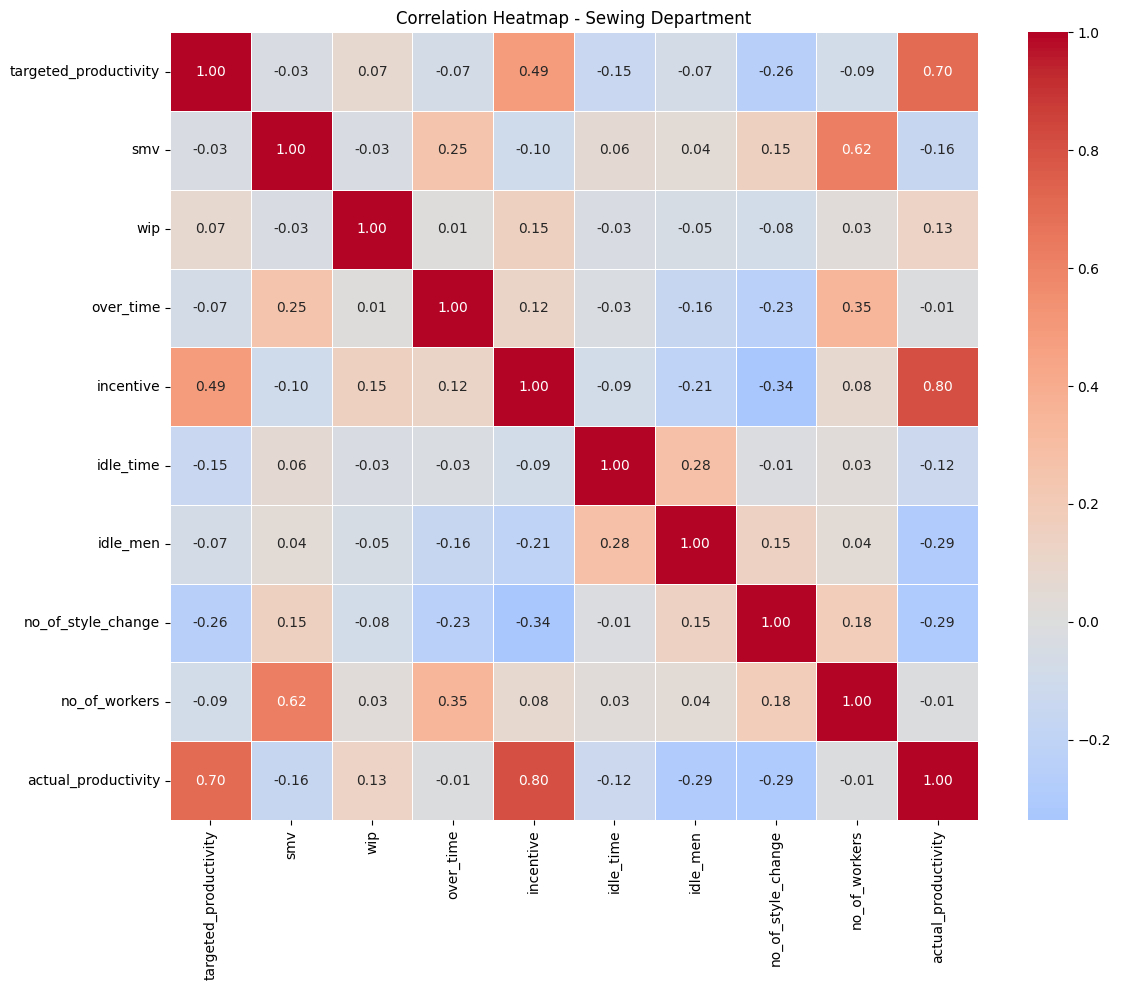

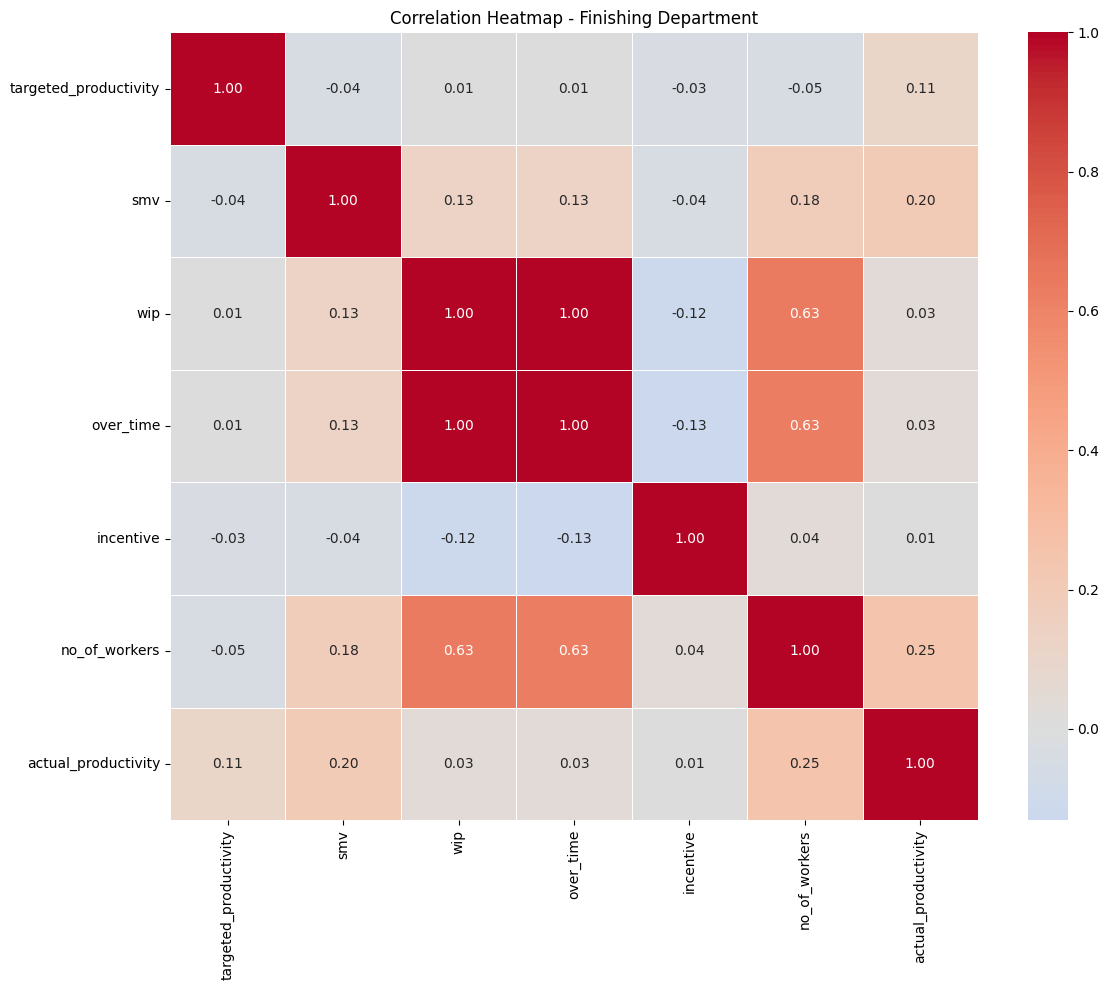

In [246]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np



# Function to calculate correlation and plot heatmap for a specific department
def plot_dept_heatmap(dept_name, filename):
    # Filter data for the specific department and select numeric columns
    dept_df = train_data[train_data['department'] == dept_name].select_dtypes(include=[np.number])

    # Drop columns that are entirely NaN or have zero variance (constant columns)
    dept_df = dept_df.dropna(axis=1, how='all')
    dept_df = dept_df.loc[:, dept_df.std() > 0]

    # Calculate the Pearson correlation matrix
    corr_matrix = dept_df.corr()

    # Create the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
    plt.title(f'Correlation Heatmap - {dept_name.capitalize()} Department')
    plt.tight_layout()

    # Save the plot
    plt.savefig(filename)

# Generate and save separate heatmaps
plot_dept_heatmap('sewing', 'corr_sewing.png') # Changed 'sweing' to 'sewing'
plot_dept_heatmap('finishing', 'corr_finishing.png')

**Sewing Department**

Spearman Correlation Heetmap

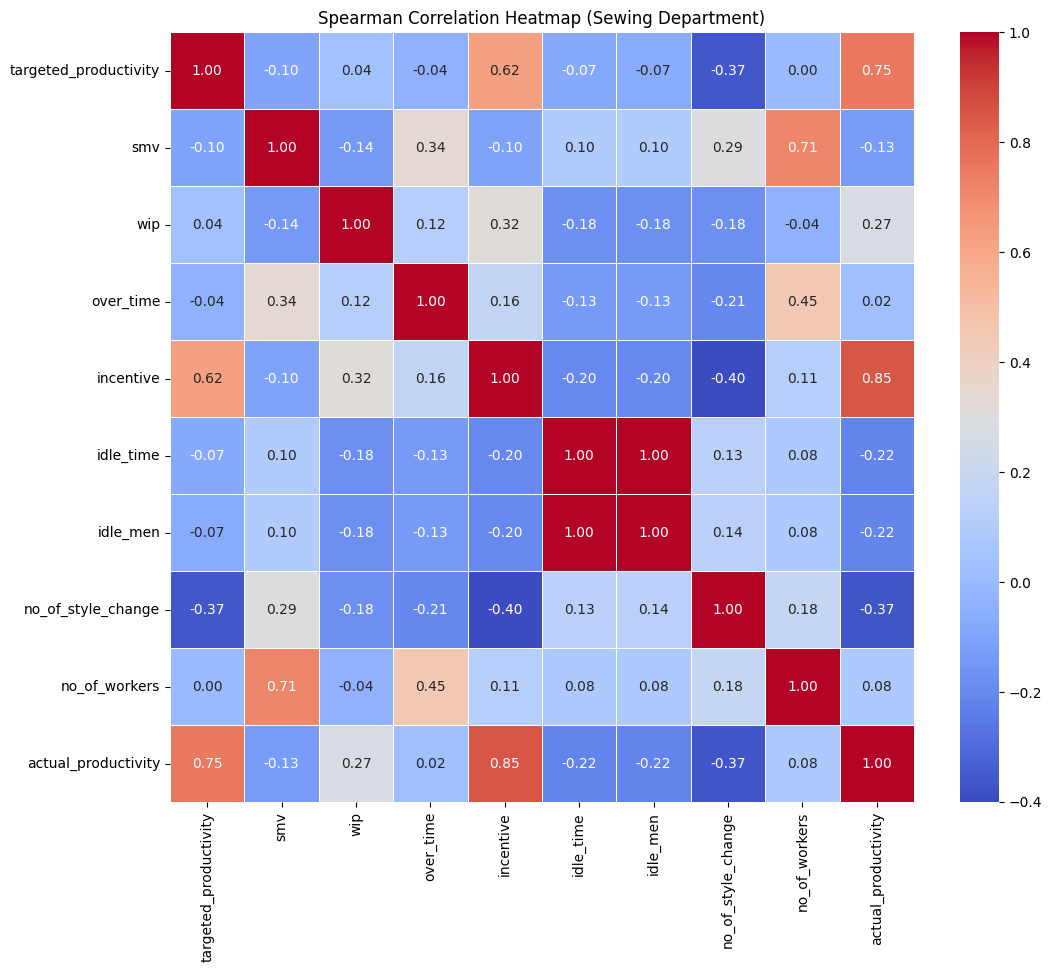

In [247]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Filter for the sewing department
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Select only numeric columns
numeric_cols = sewing_data.select_dtypes(include=['number'])

# Calculate Spearman Correlation
spearman_corr = numeric_cols.corr(method='spearman')

# Generate the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Spearman Correlation Heatmap (Sewing Department)')
plt.savefig('sewing_spearman_heatmap.png')

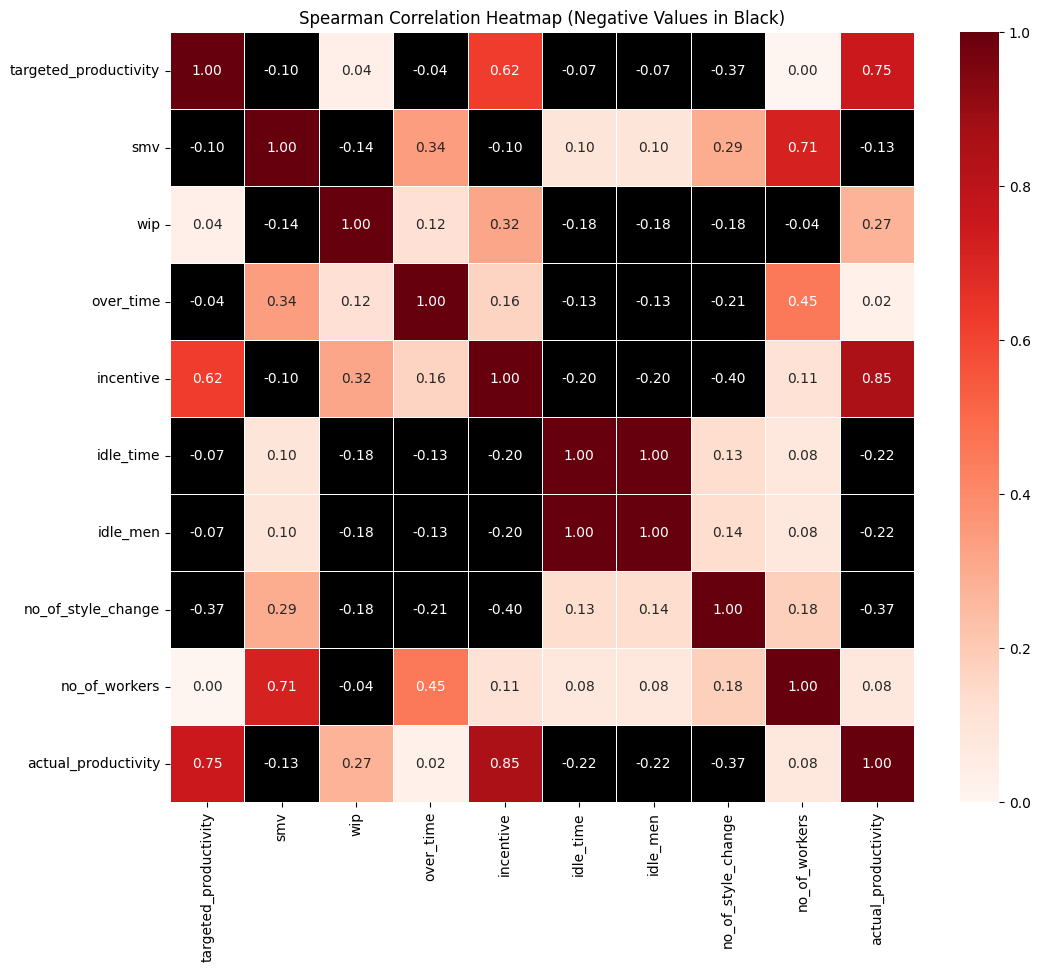

In [248]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Filter for the sewing department
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Select only numeric columns
numeric_cols = sewing_data.select_dtypes(include=['number'])

# Calculate Spearman Correlation
spearman_corr = numeric_cols.corr(method='spearman')

# 1. Prepare a colormap (e.g., 'Reds', 'viridis', or the 'warm' part of 'coolwarm')
# We'll use 'Reds' so positive correlations are shades of red
cmap = plt.get_cmap('Reds').copy()

# 2. Set the "under" color to black.
# Any value lower than the 'vmin' we set later will turn this color.
cmap.set_under('black')

# Generate the heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap=cmap,
    vmin=0,      # Set minimum to 0 so all negative values are "under" and turn black
    vmax=1,      # Scale gradient for positive correlations up to 1
    fmt=".2f",
    linewidths=0.5
)

plt.title('Spearman Correlation Heatmap (Negative Values in Black)')
plt.savefig('sewing_spearman_heatmap.png')

**Incentive vs Actual productivity**

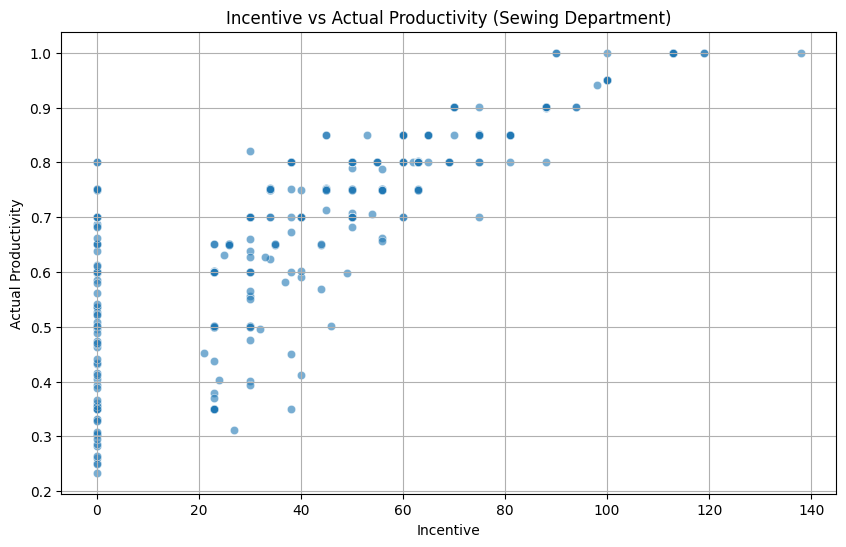

In [249]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Create the sewing dataframe
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sewing_data, x='incentive', y='actual_productivity', alpha=0.6)
plt.title('Incentive vs Actual Productivity (Sewing Department)')
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
plt.grid(True)
plt.savefig('sewing_incentive_vs_productivity.png')

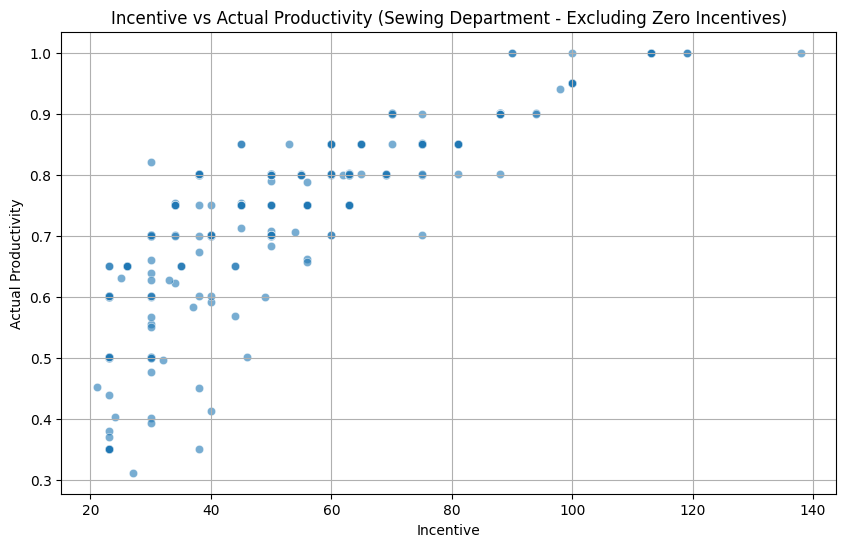

In [250]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the sewing dataframe
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Filter out rows where incentive is 0
# This removes the vertical cluster on the far left of the graph
sewing_data_filtered = sewing_data[sewing_data['incentive'] > 0]

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sewing_data_filtered, x='incentive', y='actual_productivity', alpha=0.6)

plt.title('Incentive vs Actual Productivity (Sewing Department - Excluding Zero Incentives)')
plt.xlabel('Incentive')
plt.ylabel('Actual Productivity')
plt.grid(True)
plt.savefig('sewing_incentive_vs_productivity_no_zeros.png')

Spearman Correlation Test

In [251]:
import pandas as pd
from scipy.stats import spearmanr




# Create separate dataframes for each department
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Perform Spearman correlation test for Sewing
corr_sewing, p_sewing = spearmanr(sewing_data['incentive'], sewing_data['actual_productivity'])


# Display results
print(f"Sewing - Spearman Correlation: {corr_sewing:.4f}, p-value: {p_sewing:.4e}")


Sewing - Spearman Correlation: 0.8512, p-value: 2.7565e-153


**No of Workers Vs SMV**

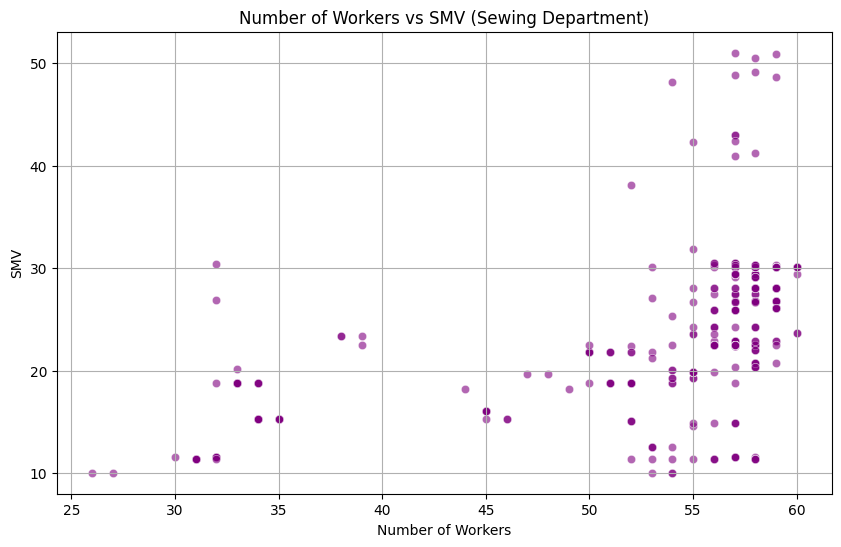

In [252]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Create the sewing dataframe
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sewing_data, x='no_of_workers', y='smv', alpha=0.6, color='purple')
plt.title('Number of Workers vs SMV (Sewing Department)')
plt.xlabel('Number of Workers')
plt.ylabel('SMV')
plt.grid(True)
plt.savefig('sewing_workers_vs_smv.png')

Spearman Correlation Test

In [253]:
import pandas as pd
from scipy.stats import spearmanr

# Create separate dataframes for each department
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Perform Spearman correlation test for Sewing
corr_sewing, p_sewing = spearmanr(sewing_data['smv'], sewing_data['no_of_workers'])


# Display results
print(f"Sewing - Spearman Correlation: {corr_sewing:.4f}, p-value: {p_sewing:.4e}")


Sewing - Spearman Correlation: 0.7110, p-value: 1.3165e-84


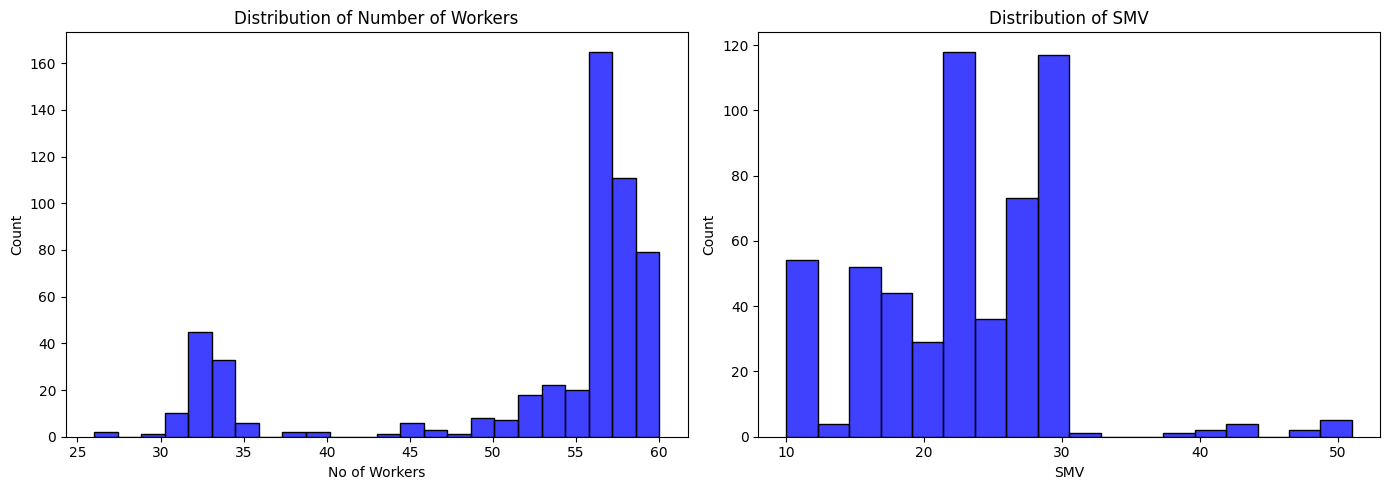

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Create the sewing dataframe
sewing_data = train_data[train_data['department'] == 'sewing'].copy()

# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for no_of_workers (kde=False removes the distribution line)
sns.histplot(sewing_data['no_of_workers'], ax=axes[0], color='blue', kde=False)
axes[0].set_title('Distribution of Number of Workers')
axes[0].set_xlabel('No of Workers')

# Histogram for smv (kde=False removes the distribution line)
sns.histplot(sewing_data['smv'], ax=axes[1], color='blue', kde=False)
axes[1].set_title('Distribution of SMV')
axes[1].set_xlabel('SMV')

plt.tight_layout()
plt.savefig('sewing_workers_smv_histograms.png')

**Finishing department**

Spearman Correlation Heetmap

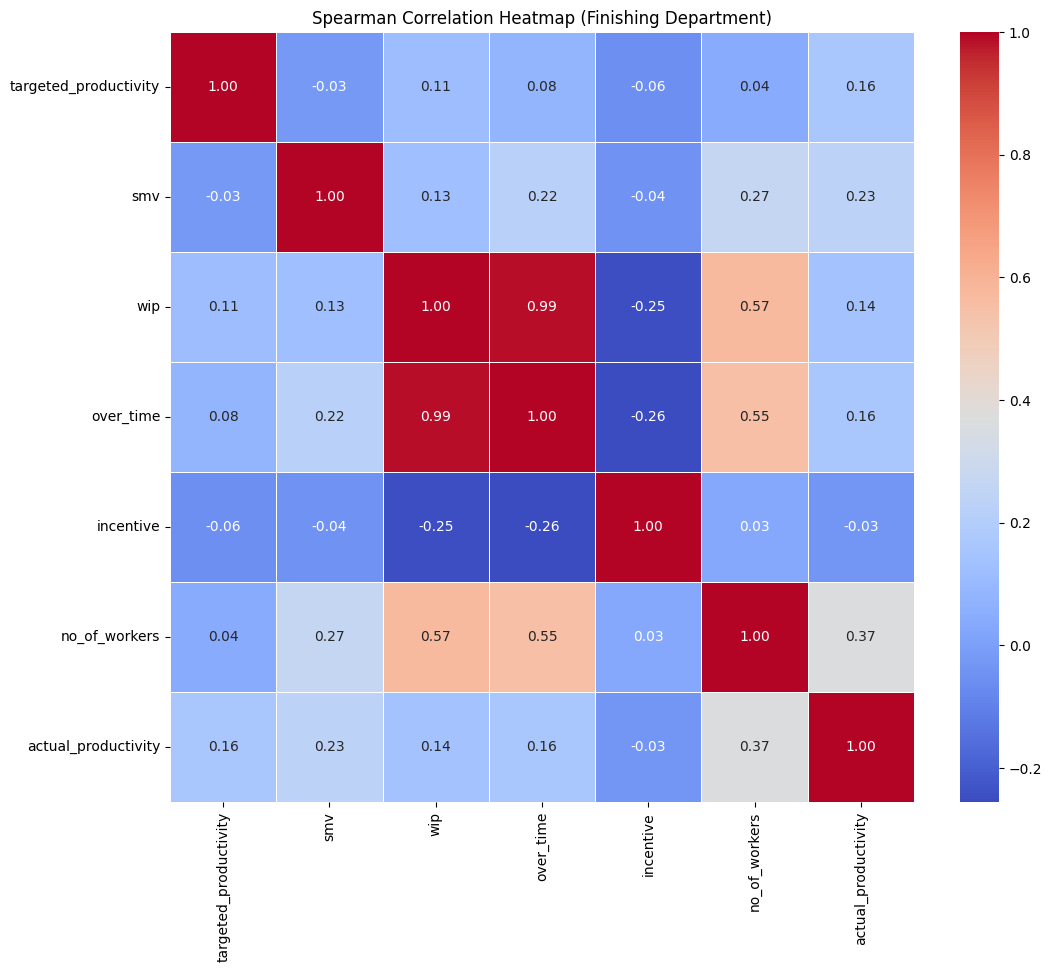

In [255]:
import pandas as pd



# Drop the specified columns
columns_to_drop = ['idle_time', 'idle_men', 'no_of_style_change']
train_data1 = train_data.drop(columns=columns_to_drop)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Filter for the finishing department
finishing_data = train_data1[train_data1['department'] == 'finishing'].copy()

# Select only numeric columns
numeric_cols_finishing = finishing_data.select_dtypes(include=['number'])

# Calculate Spearman Correlation
spearman_corr_finishing = numeric_cols_finishing.corr(method='spearman')

# Generate the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr_finishing, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Spearman Correlation Heatmap (Finishing Department)')
plt.savefig('finishing_spearman_heatmap.png')

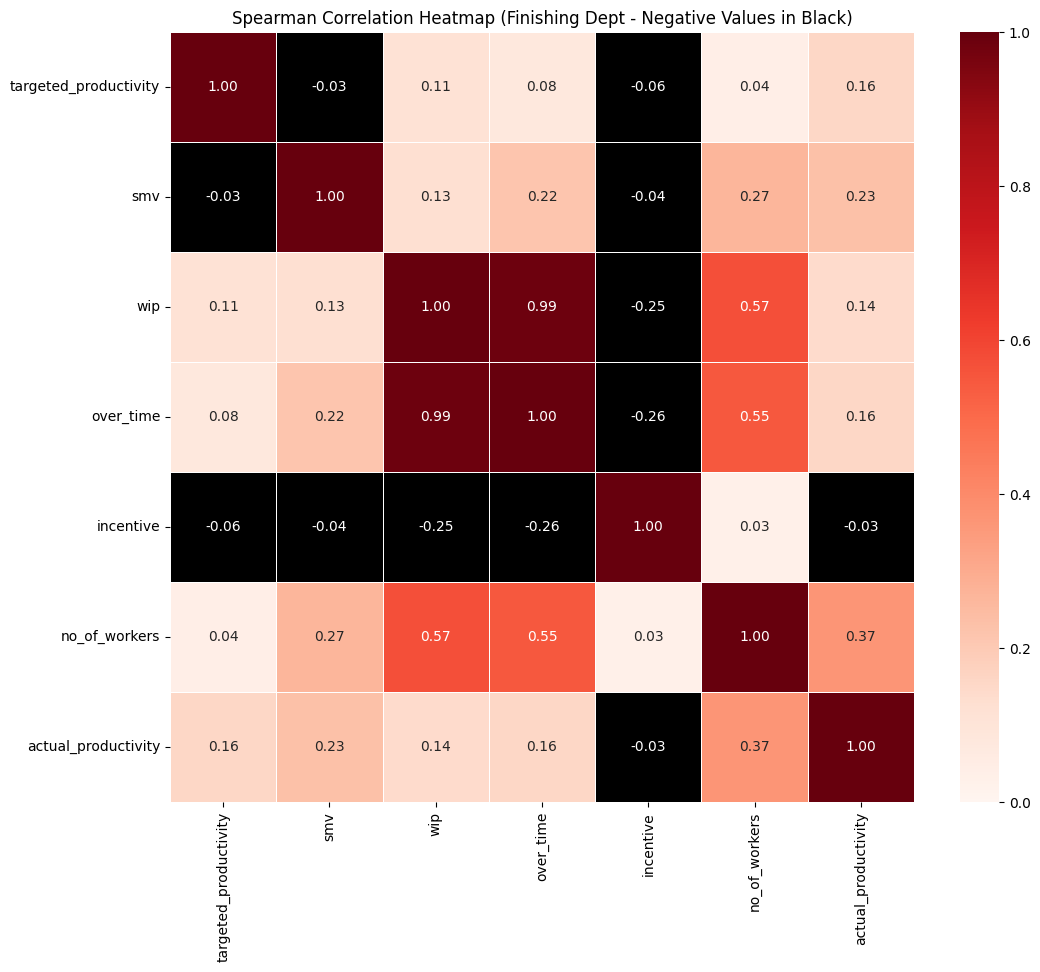

In [256]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Drop the specified columns
columns_to_drop = ['idle_time', 'idle_men', 'no_of_style_change']
train_data1 = train_data.drop(columns=columns_to_drop)

# 2. Filter for the finishing department
finishing_data = train_data1[train_data1['department'] == 'finishing'].copy()

# 3. Select only numeric columns
numeric_cols_finishing = finishing_data.select_dtypes(include=['number'])

# 4. Calculate Spearman Correlation
spearman_corr_finishing = numeric_cols_finishing.corr(method='spearman')

# 5. Setup the colormap to handle negative values as black
# We use 'Reds' for positive correlations and set everything "under" 0 to black
cmap = plt.get_cmap('Reds').copy()
cmap.set_under('black')

# 6. Generate the heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    spearman_corr_finishing,
    annot=True,
    cmap=cmap,
    vmin=0,       # Force the gradient to start at 0
    vmax=1,       # Max scale at 1.0
    fmt=".2f",
    linewidths=0.5
)

plt.title('Spearman Correlation Heatmap (Finishing Dept - Negative Values in Black)')
plt.savefig('finishing_spearman_heatmap.png')

**No of workers vs over Time**

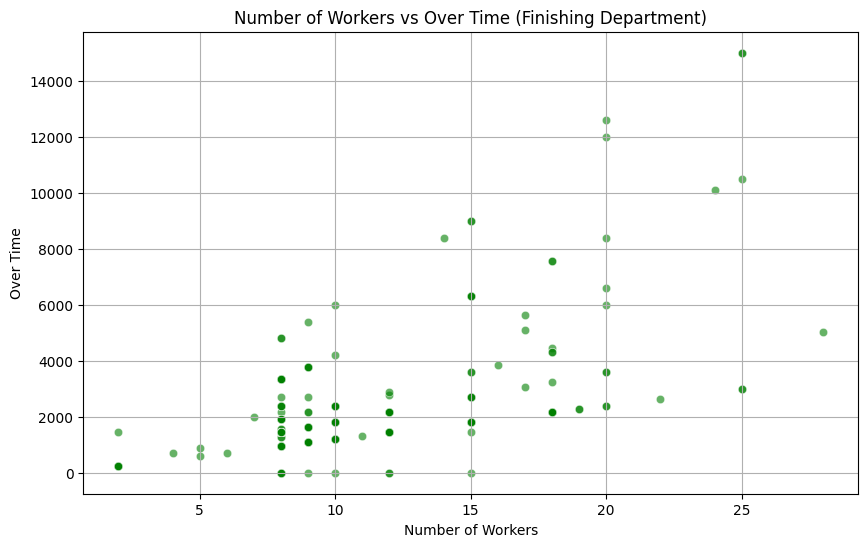

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Filter for the finishing department
finishing_data = train_data[train_data['department'] == 'finishing'].copy()

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=finishing_data, x='no_of_workers', y='over_time', alpha=0.6, color='green')
plt.title('Number of Workers vs Over Time (Finishing Department)')
plt.xlabel('Number of Workers')
plt.ylabel('Over Time')
plt.grid(True)
plt.savefig('finishing_workers_vs_overtime.png')

Spearman Correlation Test

In [258]:
import pandas as pd
from scipy.stats import spearmanr


# Filter for the finishing department and drop rows with missing values
# It is important to drop NaNs because correlation tests cannot handle empty cells
finishing_data = train_data[train_data['department'] == 'finishing'].copy()
finishing_clean = finishing_data[['over_time', 'no_of_workers']]

# Perform the Spearman correlation test
corr, p_value = spearmanr(finishing_clean['over_time'], finishing_clean['no_of_workers'])

print(f"Spearman Correlation (Finishing Department):")
print(f"Correlation coefficient: {corr:.4f}")
print(f"p-value: {p_value:.4e}")

# Interpretation
if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

Spearman Correlation (Finishing Department):
Correlation coefficient: 0.5500
p-value: 3.4892e-34
The correlation is statistically significant.


****WIP VS Over Time****

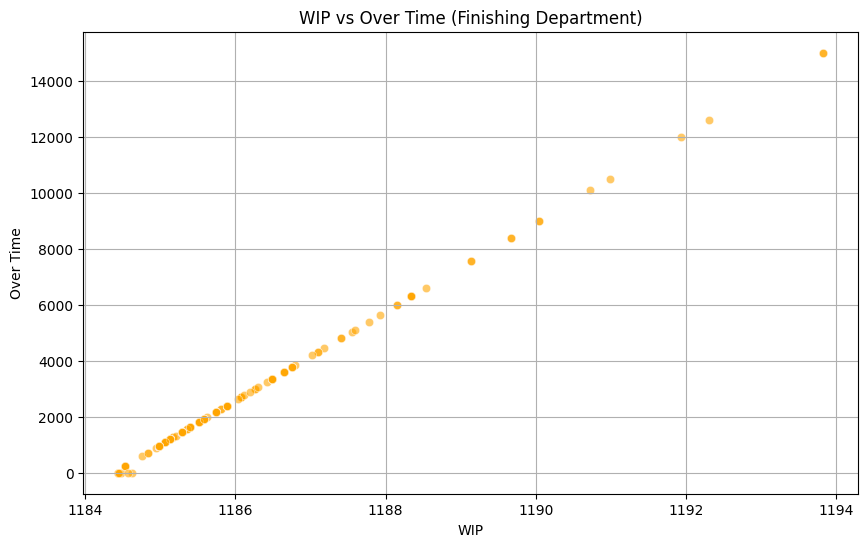

In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Filter for the finishing department
finishing_data = train_data[train_data['department'] == 'finishing'].copy()

# Drop rows with NaN in 'wip' or 'over_time'
finishing_clean = finishing_data.dropna(subset=['wip', 'over_time'])

# Check if data exists before plotting
if not finishing_clean.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=finishing_clean, x='wip', y='over_time', alpha=0.6, color='orange')
    plt.title('WIP vs Over Time (Finishing Department)')
    plt.xlabel('WIP')
    plt.ylabel('Over Time')
    plt.grid(True)
    plt.savefig('finishing_wip_vs_overtime.png')
else:
    print("There is no available data for WIP in the finishing department.")

Spearman Correlation Test

In [260]:
import pandas as pd
from scipy.stats import spearmanr



# 2. Prepare the data for the Finishing Department
finishing_data = train_data[train_data['department'] == 'finishing'].copy()

# 3. Drop rows where either 'wip' or 'over_time' is missing
# Correlation tests cannot process NaN (Not a Number) values
clean_data = finishing_data.dropna(subset=['wip', 'over_time'])

# 4. Check if we have enough data left to test
if not clean_data.empty:
    # 5. Perform the Spearman correlation test
    corr, p_value = spearmanr(clean_data['wip'], clean_data['over_time'])

    print(f"Spearman Correlation (WIP vs Over Time - Finishing):")
    print(f"Correlation coefficient: {corr:.4f}")
    print(f"p-value: {p_value:.4e}")

    if p_value < 0.05:
        print("Result: The correlation is statistically significant.")
    else:
        print("Result: The correlation is not statistically significant.")
else:
    print("Not enough data to calculate correlation for WIP in the Finishing Department.")

Spearman Correlation (WIP vs Over Time - Finishing):
Correlation coefficient: 0.9861
p-value: 0.0000e+00
Result: The correlation is statistically significant.


**No of workers and SMV**

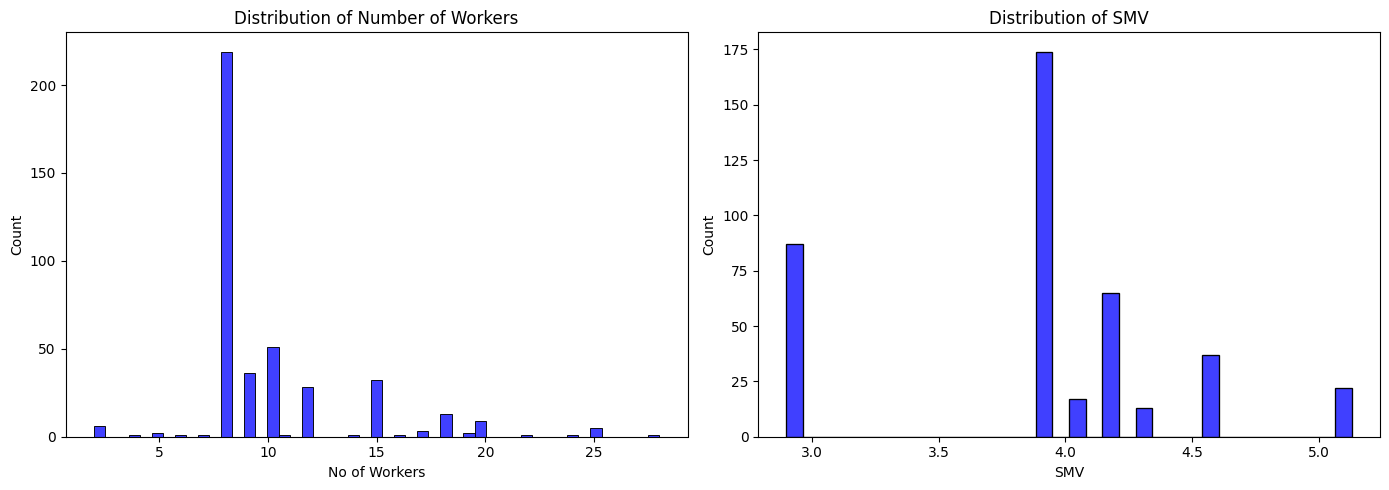

In [261]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Create the finishing dataframe
finishing_data = train_data[train_data['department'] == 'finishing'].copy()

# Create histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for no_of_workers (kde=False removes the distribution line)
sns.histplot(finishing_data['no_of_workers'], ax=axes[0], color='blue', kde=False)
axes[0].set_title('Distribution of Number of Workers')
axes[0].set_xlabel('No of Workers')

# Histogram for smv (kde=False removes the distribution line)
sns.histplot(finishing_data['smv'], ax=axes[1], color='blue', kde=False)
axes[1].set_title('Distribution of SMV')
axes[1].set_xlabel('SMV')

plt.tight_layout()
plt.savefig('finishing_workers_smv_histograms.png')

**Comparitive EDA for both departments**

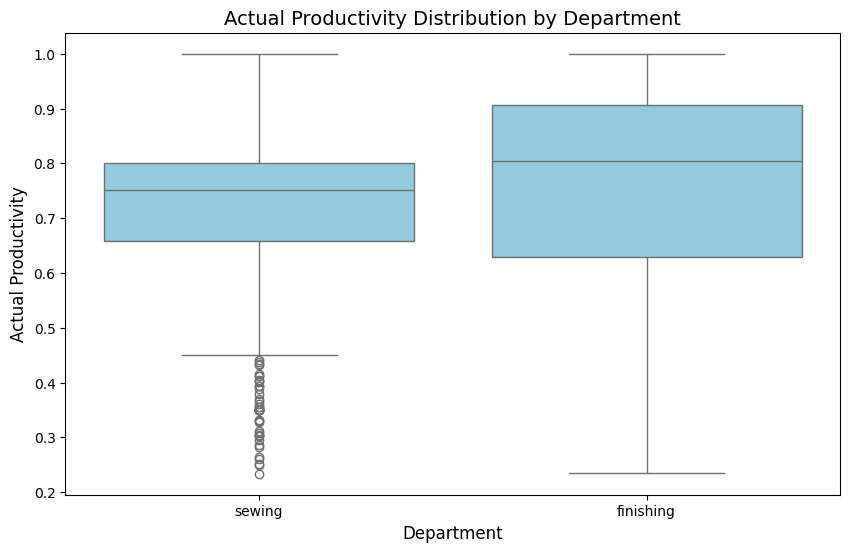

In [262]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# Create the boxplot
plt.figure(figsize=(10, 6))

# Plotting 'actual_productivity' by 'department' using train_data
# 'color' is set to 'skyblue' to ensure both boxes have the same color
sns.boxplot(x='department', y='actual_productivity', data=train_data, color='skyblue')

# Customizing the labels and title
plt.title('Actual Productivity Distribution by Department', fontsize=14)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Actual Productivity', fontsize=12)

# Display the plot
plt.show()

In [263]:
from scipy import stats

# Filter the data for each department and remove missing values
sewing_productivity = train_data[train_data['department'] == 'sewing']['actual_productivity']
finishing_productivity = train_data[train_data['department'] == 'finishing']['actual_productivity']

# Conduct Shapiro-Wilk test
stat_sewing, p_sewing = stats.shapiro(sewing_productivity)
stat_finishing, p_finishing = stats.shapiro(finishing_productivity)

# Display the results
print(f"Sewing - Statistic: {stat_sewing:.4f}, p-value: {p_sewing:.4e}")
print(f"Finishing - Statistic: {stat_finishing:.4f}, p-value: {p_finishing:.4e}")

Sewing - Statistic: 0.8983, p-value: 1.6979e-18
Finishing - Statistic: 0.9178, p-value: 2.8756e-14


In [264]:
import pandas as pd
from scipy.stats import mannwhitneyu


# Filter the data for each department and remove missing values
sewing_productivity = train_data[train_data['department'] == 'sewing']['actual_productivity']
finishing_productivity = train_data[train_data['department'] == 'finishing']['actual_productivity']

# Perform the Mann-Whitney U test
stat, p_value = mannwhitneyu(sewing_productivity, finishing_productivity, alternative='two-sided')

# Display the results
print(f"Mann-Whitney U Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4e}")

Mann-Whitney U Test Statistic: 93854.0000
p-value: 1.1237e-05


**Targeted Productivity distriution**

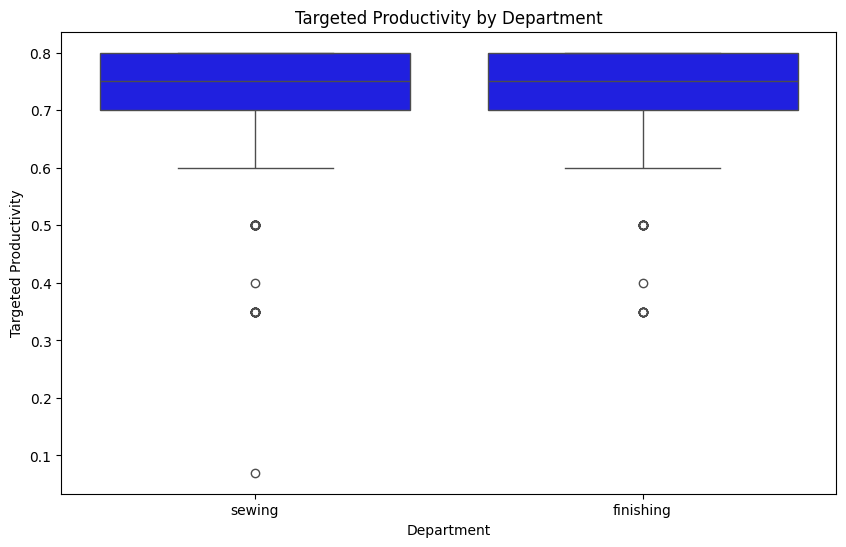

In [265]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Create the boxplot with blue color
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data, x='department', y='targeted_productivity', color='blue')
plt.title('Targeted Productivity by Department')
plt.xlabel('Department')
plt.ylabel('Targeted Productivity')
plt.savefig('targeted_productivity_boxplot_blue.png')

In [266]:
import pandas as pd
from scipy.stats import shapiro, mannwhitneyu

# Split the data
sewing_data = train_data[train_data['department'] == 'sewing']['targeted_productivity']
finishing_data = train_data[train_data['department'] == 'finishing']['targeted_productivity']

# 1. Shapiro-Wilk Test for Normality
# If p-value < 0.05, the data is NOT normally distributed
stat_s, p_s = shapiro(sewing_data)
stat_f, p_f = shapiro(finishing_data)

print(f"Shapiro-Wilk (Sewing): Statistics={stat_s:.4f}, p-value={p_s:.4e}")
print(f"Shapiro-Wilk (Finishing): Statistics={stat_f:.4f}, p-value={p_f:.4e}")

# 2. Mann-Whitney U Test
# Compares if there is a significant difference between the two groups
stat_mw, p_mw = mannwhitneyu(sewing_data, finishing_data)

print(f"\nMann-Whitney U Test: Statistics={stat_mw:.4f}, p-value={p_mw:.4e}")

Shapiro-Wilk (Sewing): Statistics=0.7205, p-value=4.1600e-29
Shapiro-Wilk (Finishing): Statistics=0.7130, p-value=4.6278e-26

Mann-Whitney U Test: Statistics=106856.5000, p-value=1.6248e-01


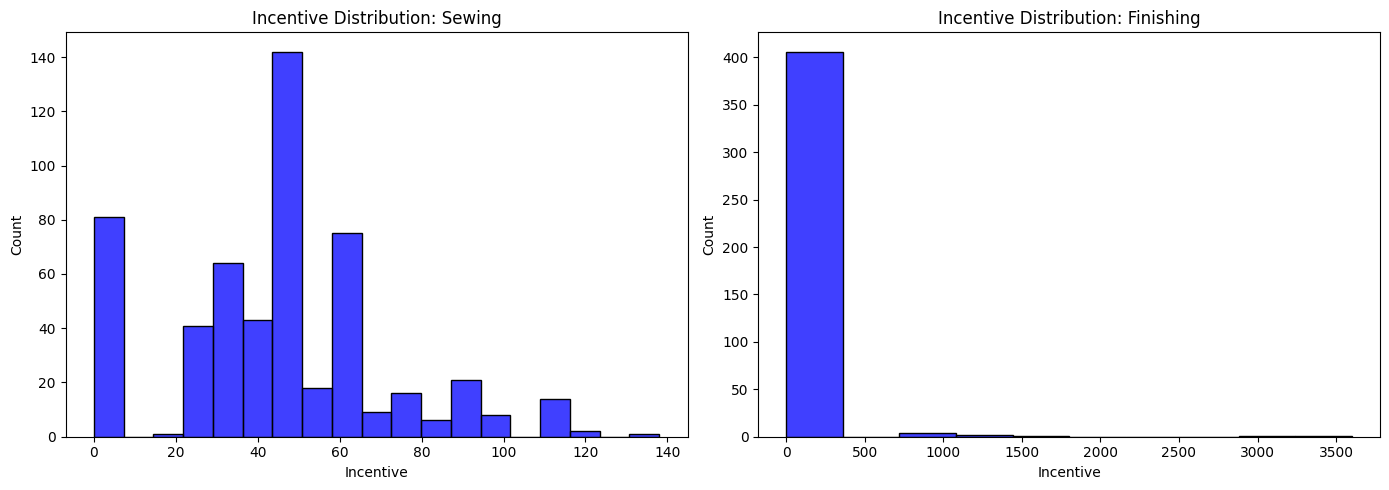

In [267]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Separate data
sewing_data = train_data[train_data['department'] == 'sewing']
finishing_data = train_data[train_data['department'] == 'finishing']

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(sewing_data['incentive'], ax=axes[0], color='blue')
axes[0].set_title('Incentive Distribution: Sewing')
axes[0].set_xlabel('Incentive')

sns.histplot(finishing_data['incentive'], ax=axes[1], color='blue')
axes[1].set_title('Incentive Distribution: Finishing')
axes[1].set_xlabel('Incentive')

plt.tight_layout()
plt.savefig('incentive_histograms_separate.png')

/tmp/ipykernel_171/2873363067.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_data, x='department', y='over_time', palette='Blues')


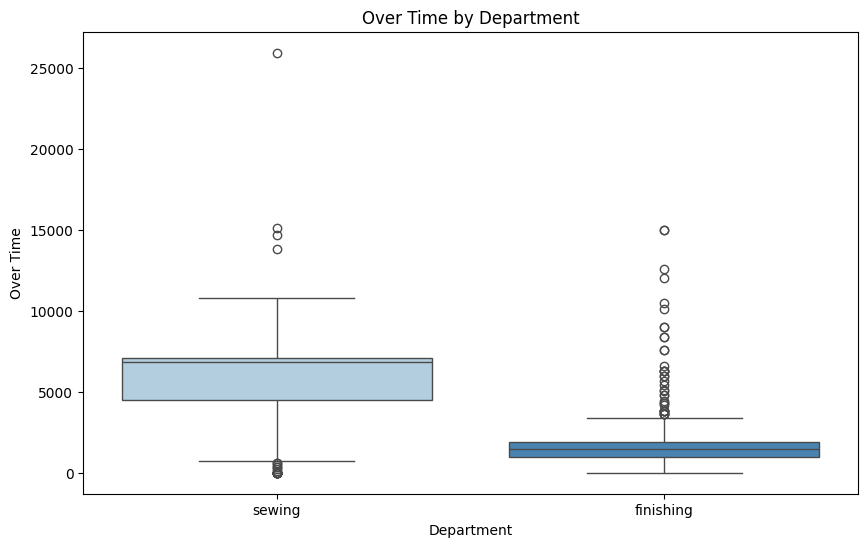

In [268]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# Create the boxplot for over_time
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_data, x='department', y='over_time', palette='Blues')
plt.title('Over Time by Department')
plt.xlabel('Department')
plt.ylabel('Over Time')
plt.savefig('over_time_boxplot.png')

In [269]:
import pandas as pd
from scipy.stats import shapiro, mannwhitneyu


# Subset 'over_time' for both departments and remove missing values
sewing_overtime = train_data[train_data['department'] == 'sewing']['over_time'].dropna()
finishing_overtime = train_data[train_data['department'] == 'finishing']['over_time'].dropna()

# 1. Shapiro-Wilk Test for Normality
# Null Hypothesis (H0): The data is normally distributed
stat_s, p_s = shapiro(sewing_overtime)
stat_f, p_f = shapiro(finishing_overtime)

print(f"Shapiro-Wilk (Sewing) - Over Time: Statistics={stat_s:.4f}, p-value={p_s:.4e}")
print(f"Shapiro-Wilk (Finishing) - Over Time: Statistics={stat_f:.4f}, p-value={p_f:.4e}")

# 2. Mann-Whitney U Test
# Null Hypothesis (H0): There is no difference in the distribution of overtime between the two groups
stat_mw, p_mw = mannwhitneyu(sewing_overtime, finishing_overtime)

print(f"\nMann-Whitney U Test - Over Time: Statistics={stat_mw:.4f}, p-value={p_mw:.4e}")

Shapiro-Wilk (Sewing) - Over Time: Statistics=0.9266, p-value=1.2646e-15
Shapiro-Wilk (Finishing) - Over Time: Statistics=0.5811, p-value=2.2178e-30

Mann-Whitney U Test - Over Time: Statistics=204335.0000, p-value=1.6808e-104


--- Non-Parametric Significance Test (Mann-Whitney U) ---
Cluster 0 Median Productivity: 0.7506
Cluster 1 Median Productivity: 0.8035
U-Statistic: 93854.0
P-Value: 1.1237e-05

Result: Reject Null Hypothesis. There is a statistically significant difference 
between the productivity levels of the two clusters (p < 0.05).


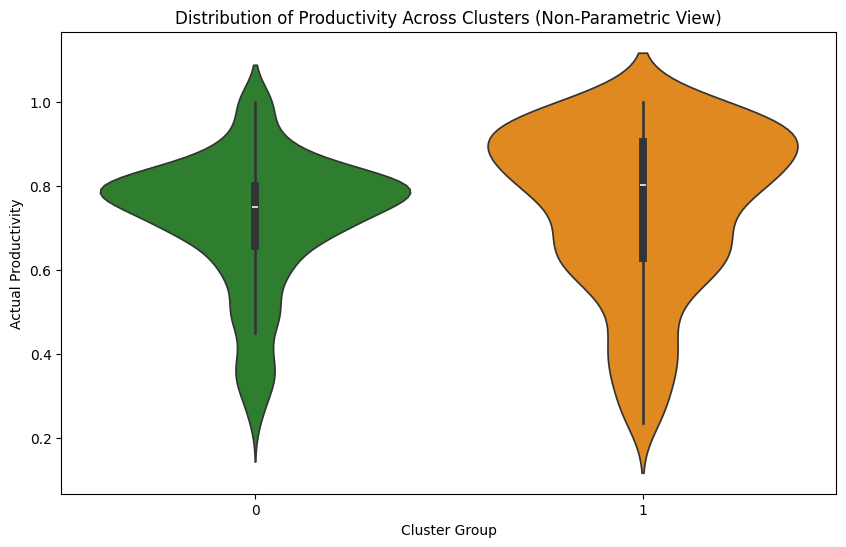

In [270]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data for productivity by cluster
# Ensure 'cluster' and 'actual_productivity' are the correct column names from your notebook
cluster_0 = train_summary_df[train_summary_df['cluster'] == 0]['actual_productivity']
cluster_1 = train_summary_df[train_summary_df['cluster'] == 1]['actual_productivity']

# 2. Perform Mann-Whitney U Test (Non-Parametric)
# 'two-sided' tests if the distributions are different in any way
u_stat, p_val = stats.mannwhitneyu(cluster_0, cluster_1, alternative='two-sided')

print("--- Non-Parametric Significance Test (Mann-Whitney U) ---")
print(f"Cluster 0 Median Productivity: {cluster_0.median():.4f}")
print(f"Cluster 1 Median Productivity: {cluster_1.median():.4f}")
print(f"U-Statistic: {u_stat}")
print(f"P-Value: {p_val:.4e}")

# 3. Decision Logic
alpha = 0.05
if p_val < alpha:
    print(f"\nResult: Reject Null Hypothesis. There is a statistically significant difference \n"
          f"between the productivity levels of the two clusters (p < {alpha}).")
else:
    print(f"\nResult: Fail to Reject Null Hypothesis. No statistically significant difference \n"
          f"detected between clusters (p > {alpha}).")

# 4. Visualization (Violin plot is excellent for non-parametric data)
plt.figure(figsize=(10, 6))
sns.violinplot(x='cluster', y='actual_productivity', data=train_summary_df, hue='cluster', palette=['#228B22', '#FF8C00'], legend=False) # Updated for FutureWarning
plt.title('Distribution of Productivity Across Clusters (Non-Parametric View)')
plt.ylabel('Actual Productivity')
plt.xlabel('Cluster Group')
plt.show()

--- Chi-Square Test: Cluster vs Department ---
Chi-Square Statistic: 952.9326
P-Value: 3.0568e-209

Result: Significant association (p < 0.05).
The clusters are not distributed evenly across departments.


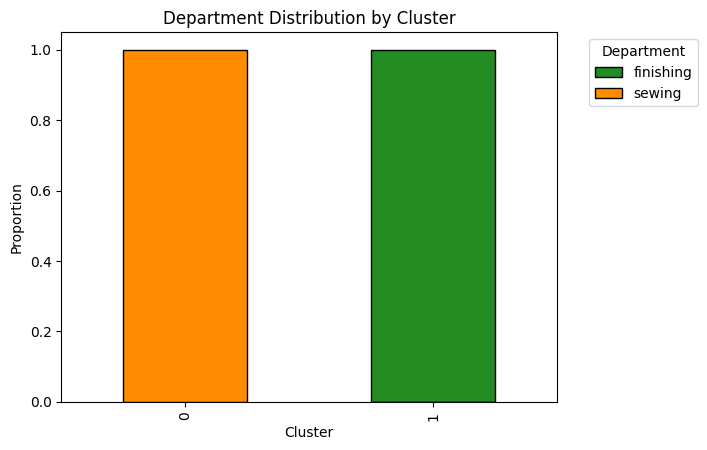

In [271]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a contingency table (e.g., Cluster vs Department)
# Replace 'department' with any categorical column you want to test
contingency_table = pd.crosstab(train_summary_df['cluster'], train_summary_df['department'])

# 2. Perform the Chi-Square Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table)

print(f"--- Chi-Square Test: Cluster vs Department ---")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val:.4e}")

# 3. Interpretation
alpha = 0.05
if p_val < alpha:
    print(f"\nResult: Significant association (p < {alpha}).")
    print("The clusters are not distributed evenly across departments.")
else:
    print(f"\nResult: No significant association (p > {alpha}).")
    print("The clusters appear to be independent of department.")

# 4. Visualization (Stacked Bar Chart)
contingency_table_pct = contingency_table.div(contingency_table.sum(1), axis=0)
contingency_table_pct.plot(kind='bar', stacked=True, color=['#228B22', '#FF8C00', '#FFFFFF'], edgecolor='black')
plt.title('Department Distribution by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1))
plt.show()

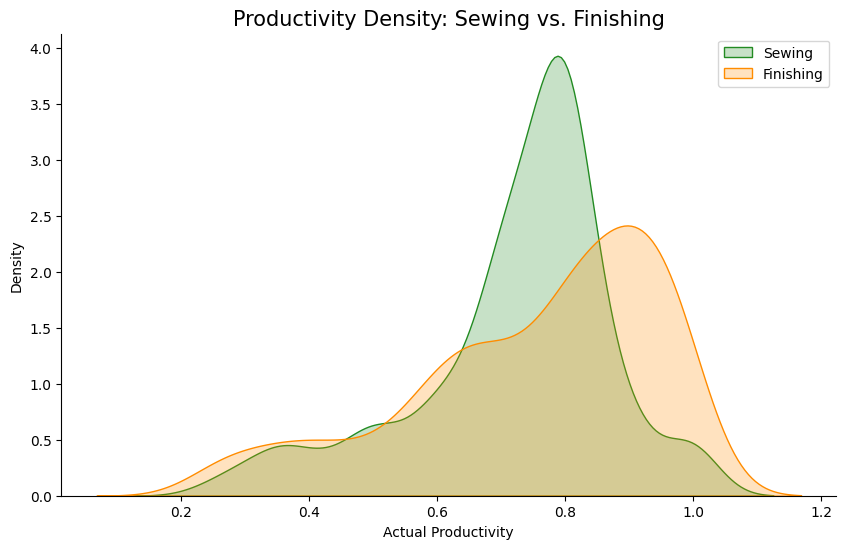

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Using KDE plots to see the "shape" of productivity
sns.kdeplot(data=df[df['department']=='sewing'], x='actual_productivity',
            label='Sewing', fill=True, color='#228B22')
sns.kdeplot(data=df[df['department']=='finishing'], x='actual_productivity',
            label='Finishing', fill=True, color='#FF8C00')

plt.title('Productivity Density: Sewing vs. Finishing', fontsize=15)
plt.xlabel('Actual Productivity')
plt.ylabel('Density')
plt.legend()
sns.despine()
plt.show()

<Figure size 1000x600 with 0 Axes>

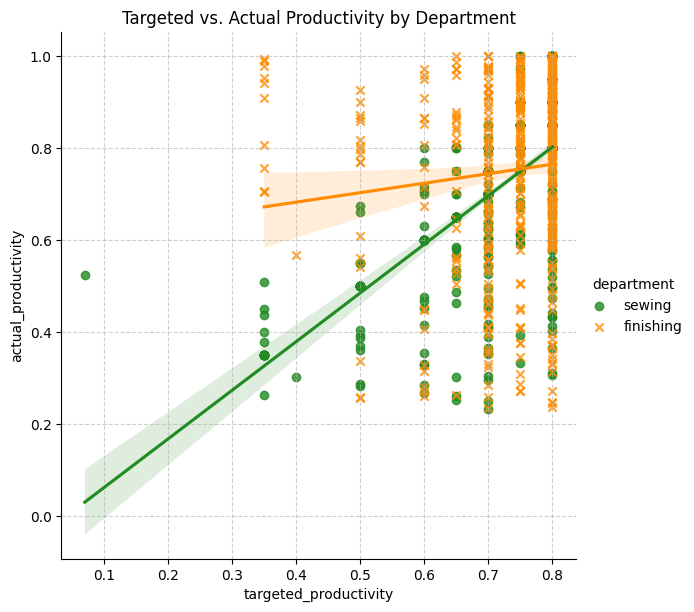

In [273]:
plt.figure(figsize=(10, 6))
sns.lmplot(x='targeted_productivity', y='actual_productivity', hue='department',
           data=df, palette=['#228B22', '#FF8C00'], markers=["o", "x"], height=6)

plt.title('Targeted vs. Actual Productivity by Department')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

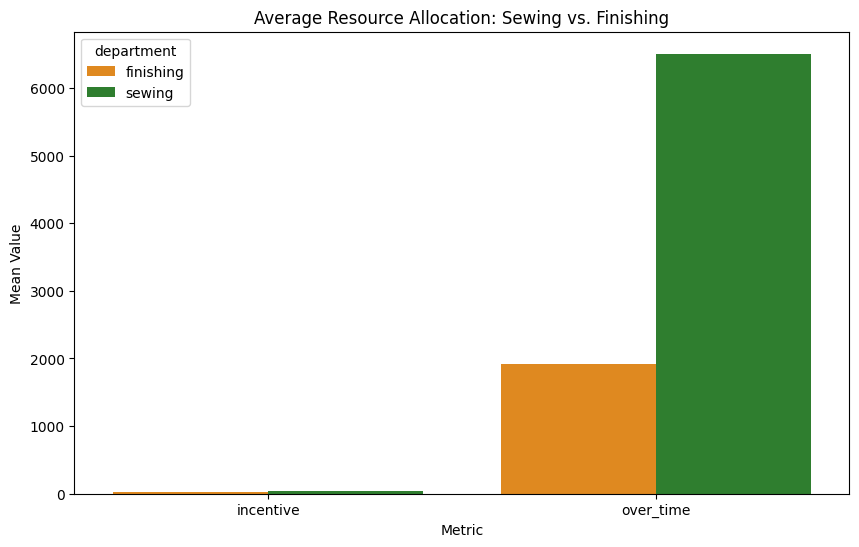

In [274]:
# Melting the dataframe to plot two metrics side-by-side
resource_df = df.groupby('department')[['incentive', 'over_time']].mean().reset_index()
resource_melted = resource_df.melt(id_vars='department', var_name='Metric', value_name='Average Value')

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Average Value', hue='department', data=resource_melted,
            palette=['#FF8C00', '#228B22'])

plt.title('Average Resource Allocation: Sewing vs. Finishing')
plt.ylabel('Mean Value')
plt.show()

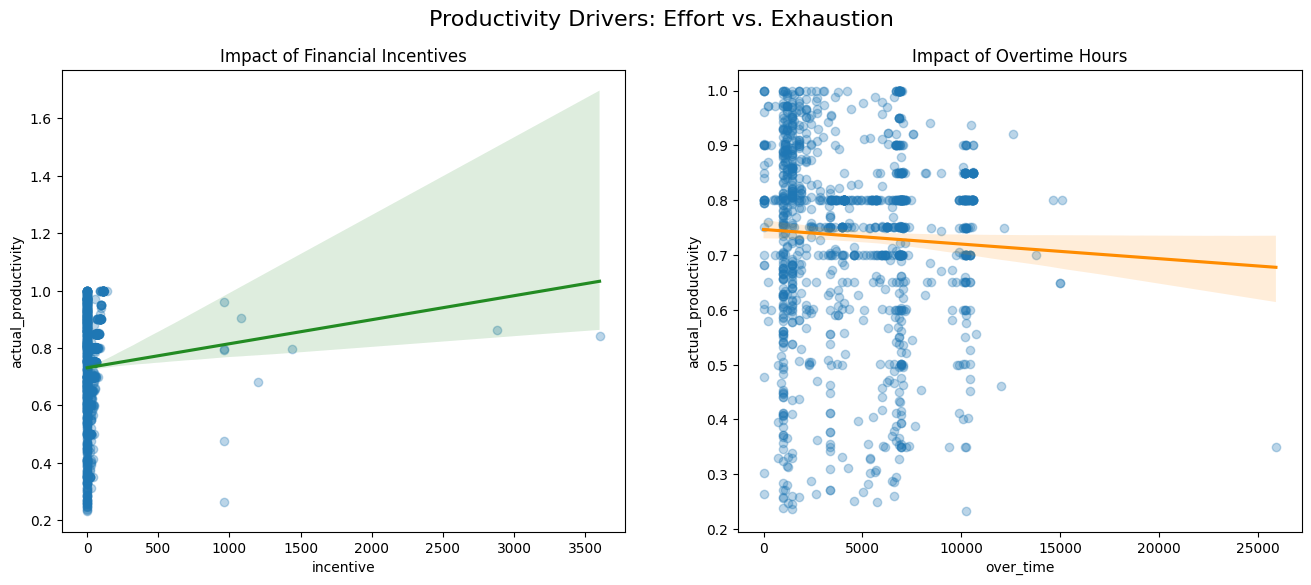

In [275]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Incentive vs Productivity
sns.regplot(x='incentive', y='actual_productivity', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'#228B22'}, ax=ax[0])
ax[0].set_title('Impact of Financial Incentives')

# 2. Overtime vs Productivity
sns.regplot(x='over_time', y='actual_productivity', data=df,
            scatter_kws={'alpha':0.3}, line_kws={'color':'#FF8C00'}, ax=ax[1])
ax[1].set_title('Impact of Overtime Hours')

plt.suptitle('Productivity Drivers: Effort vs. Exhaustion', fontsize=16)
plt.show()

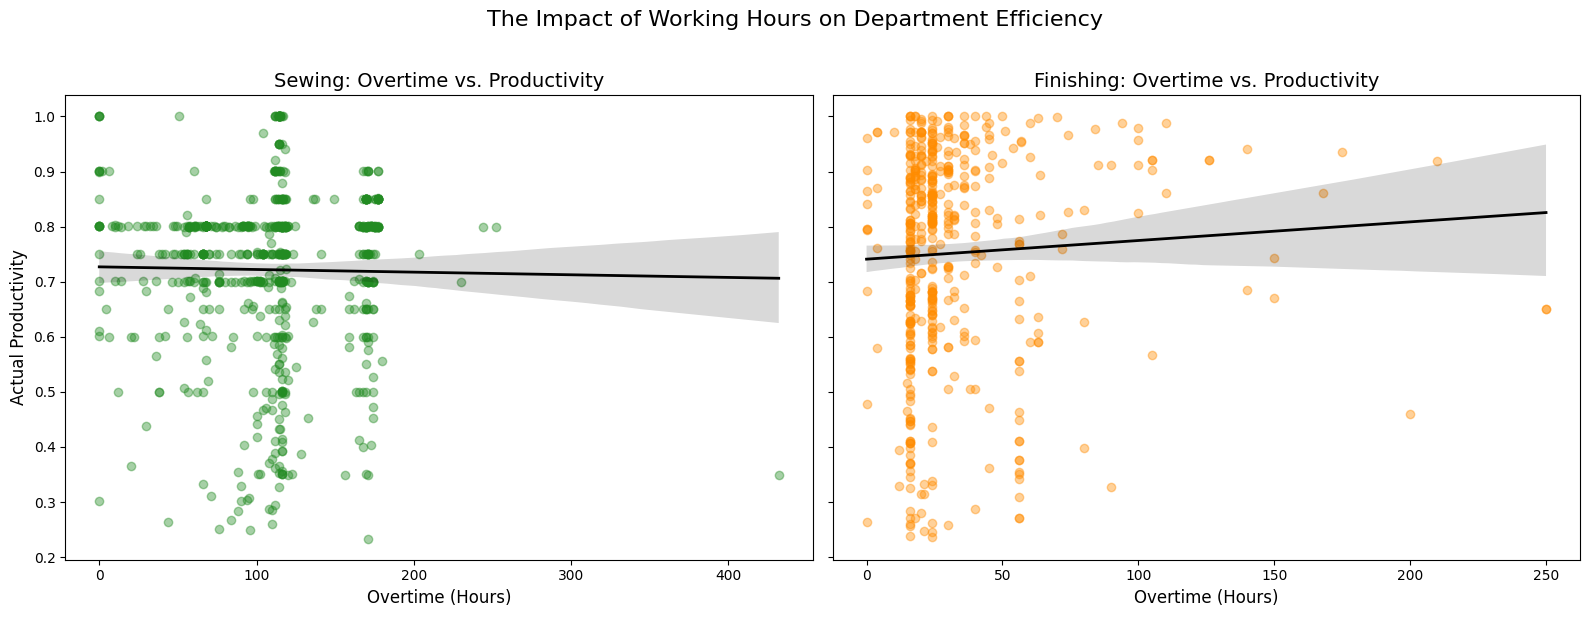

In [276]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a copy and convert Overtime from minutes to hours
# In this dataset, overtime is recorded as the total minutes for the team
df_plot = df.copy()
df_plot['over_time_hours'] = df_plot['over_time'] / 60

# 2. Setup the figure for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Plot 1: Sewing Department ---
sns.regplot(
    data=df_plot[df_plot['department'] == 'sewing'],
    x='over_time_hours',
    y='actual_productivity',
    ax=axes[0],
    scatter_kws={'alpha':0.4, 'color':'#228B22'},
    line_kws={'color':'black', 'linewidth':2}
)
axes[0].set_title('Sewing: Overtime vs. Productivity', fontsize=14)
axes[0].set_xlabel('Overtime (Hours)', fontsize=12)
axes[0].set_ylabel('Actual Productivity', fontsize=12)

# --- Plot 2: Finishing Department ---
sns.regplot(
    data=df_plot[df_plot['department'] == 'finishing'],
    x='over_time_hours',
    y='actual_productivity',
    ax=axes[1],
    scatter_kws={'alpha':0.4, 'color':'#FF8C00'},
    line_kws={'color':'black', 'linewidth':2}
)
axes[1].set_title('Finishing: Overtime vs. Productivity', fontsize=14)
axes[1].set_xlabel('Overtime (Hours)', fontsize=12)
axes[1].set_ylabel('') # Hidden because of sharey=True

plt.suptitle('The Impact of Working Hours on Department Efficiency', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

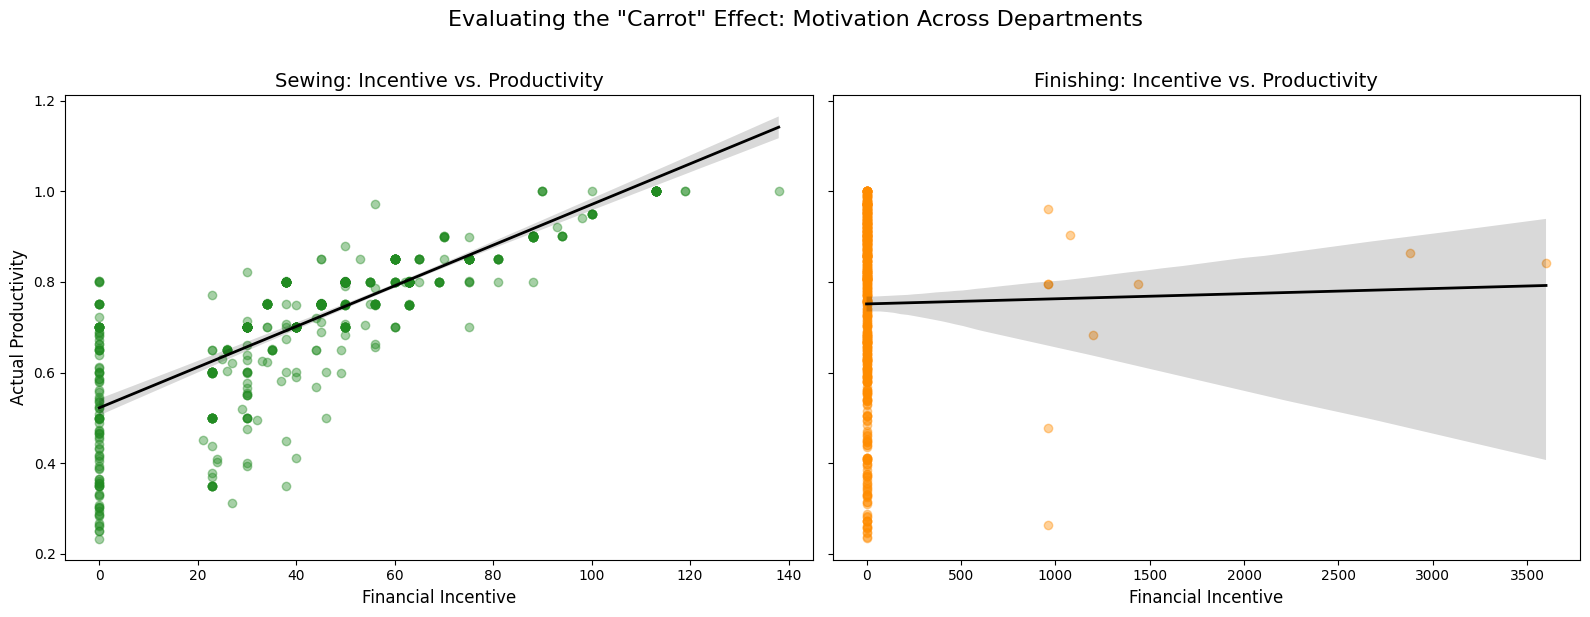

In [277]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setup the figure for two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Plot 1: Sewing Department ---
sns.regplot(
    data=df[df['department'] == 'sewing'],
    x='incentive',
    y='actual_productivity',
    ax=axes[0],
    scatter_kws={'alpha':0.4, 'color':'#228B22'}, # Green for Sewing
    line_kws={'color':'black', 'linewidth':2}
)
axes[0].set_title('Sewing: Incentive vs. Productivity', fontsize=14)
axes[0].set_xlabel('Financial Incentive', fontsize=12)
axes[0].set_ylabel('Actual Productivity', fontsize=12)

# --- Plot 2: Finishing Department ---
sns.regplot(
    data=df[df['department'] == 'finishing'],
    x='incentive',
    y='actual_productivity',
    ax=axes[1],
    scatter_kws={'alpha':0.4, 'color':'#FF8C00'}, # Orange for Finishing
    line_kws={'color':'black', 'linewidth':2}
)
axes[1].set_title('Finishing: Incentive vs. Productivity', fontsize=14)
axes[1].set_xlabel('Financial Incentive', fontsize=12)
axes[1].set_ylabel('') # Hidden because of sharey=True

plt.suptitle('Evaluating the "Carrot" Effect: Motivation Across Departments', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [278]:
# Count the occurrences of each department in the training set
department_counts = train_data['department'].value_counts()

print("Training Set Department Counts:")
print(department_counts)

Training Set Department Counts:
department
sewing       542
finishing    415
Name: count, dtype: int64


##VIF

In [279]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, cluster_id):
    # 1. Filter numerical columns only
    # (Exclude categorical and the cluster label itself)
    numerical_df = df[df['cluster'] == cluster_id].select_dtypes(include=['number']).drop(columns=['cluster'], errors='ignore')

    # 2. VIF requires a constant (intercept) to be added to the model
    X = add_constant(numerical_df)

    # 3. Calculate VIF for each feature
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

    # Remove the constant row for the final report
    return vif_data[vif_data['Feature'] != 'const']

# Assuming X_train_final contains the 'cluster' column
vif_cluster_0 = calculate_vif(X_train_final, 0)
vif_cluster_1 = calculate_vif(X_train_final, 1)

print("### VIF VALUES FOR CLUSTER 0 ###")
print(vif_cluster_0.sort_values(by="VIF", ascending=False).to_string(index=False))

print("\n### VIF VALUES FOR CLUSTER 1 ###")
print(vif_cluster_1.sort_values(by="VIF", ascending=False).to_string(index=False))

### VIF VALUES FOR CLUSTER 0 ###
              Feature      VIF
        no_of_workers 1.974628
                  smv 1.748833
            incentive 1.611515
targeted_productivity 1.453546
   no_of_style_change 1.350250
            over_time 1.342346
             idle_men 1.170313
            idle_time 1.119396
                  wip 1.027299

### VIF VALUES FOR CLUSTER 1 ###
              Feature          VIF
            over_time          inf
                  wip          inf
            incentive          inf
        no_of_workers 4.503600e+15
                  smv 3.546141e+13
targeted_productivity 6.836095e+08
            idle_time          NaN
             idle_men          NaN
   no_of_style_change          NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


##Mutual Information

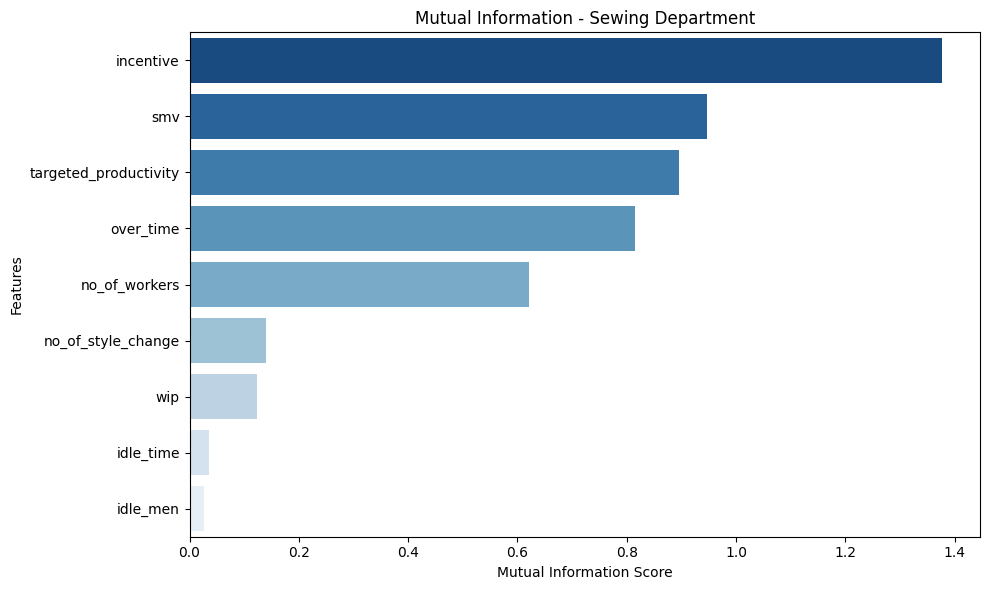

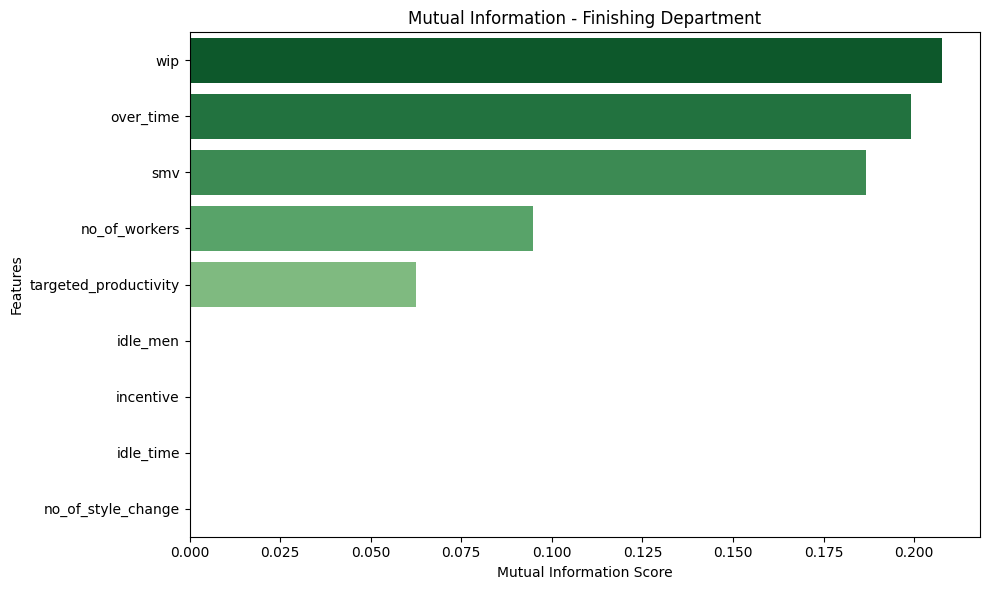

In [280]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
import numpy as np



def calculate_mi(dept_name):
    # Filter for the department
    dept_df = train_data[train_data['department'] == dept_name].copy()

    # Select numeric columns
    dept_df = dept_df.select_dtypes(include=[np.number])

    # Drop columns that are completely empty (NaN) for this specific department (e.g., wip in Finishing)
    dept_df = dept_df.dropna(axis=1, how='all')

    # Drop any remaining rows with NaNs
    dept_df = dept_df.dropna()

    if dept_df.empty or 'actual_productivity' not in dept_df.columns:
        return None

    X = dept_df.drop(columns=['actual_productivity'])
    y = dept_df['actual_productivity']

    # Calculate Mutual Information
    mi_scores = mutual_info_regression(X, y, random_state=42)
    return pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Calculate MI scores for both departments
sewing_mi = calculate_mi('sewing') # Changed 'sweing' to 'sewing'
finishing_mi = calculate_mi('finishing')

# Plot 1: Sewing Department
plt.figure(figsize=(10, 6))
sns.barplot(x=sewing_mi.values, y=sewing_mi.index, palette='Blues_r', hue=sewing_mi.index, legend=False)
plt.title('Mutual Information - Sewing Department')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('mi_sewing_train.png')

# Plot 2: Finishing Department
plt.figure(figsize=(10, 6))
sns.barplot(x=finishing_mi.values, y=finishing_mi.index, palette='Greens_r', hue=finishing_mi.index, legend=False)
plt.title('Mutual Information - Finishing Department')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('mi_finishing_train.png')

##Models

In [281]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def evaluate_models_by_cluster(X_train_df, X_test_df, y_train_ser, y_test_ser, cluster_id):
    # Filter data for the specific cluster
    X_train_c = X_train_df[X_train_df['cluster'] == cluster_id].drop(columns=['cluster'])
    y_train_c = y_train_ser[X_train_df['cluster'] == cluster_id]

    X_test_c = X_test_df[X_test_df['cluster'] == cluster_id].drop(columns=['cluster'])
    y_test_c = y_test_ser[X_test_df['cluster'] == cluster_id]

    # Identify numerical and categorical columns
    numerical_cols = X_train_c.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X_train_c.select_dtypes(include='object').columns.tolist()

    # Preprocessing Pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

    # Model and Parameter definitions
    # Note: We use aggressive regularization for Cluster 1 (Finishing)
    models_and_params = {
        "Ridge": {
            "model": Ridge(random_state=42),
            "params": {'regressor__alpha': [0.1, 1, 10, 50, 100]}
        },
        "Lasso": {
            "model": Lasso(random_state=42, max_iter=10000),
            "params": {'regressor__alpha': [0.001, 0.01, 0.1, 1]}
        },
        "ElasticNet": {
            "model": ElasticNet(random_state=42),
            "params": {'regressor__alpha': [0.01, 0.1, 1], 'regressor__l1_ratio': [0.2, 0.5, 0.8]}
        },
        "Random Forest": {
            "model": RandomForestRegressor(random_state=42),
            "params": {
                'regressor__n_estimators': [100, 200],
                'regressor__max_depth': [3, 5, 8], # Lowered to prevent the 0.97 R2 overfit
                'regressor__min_samples_leaf': [5, 10]
            }
        },
        "XGBoost": {
            "model": XGBRegressor(random_state=42, eval_metric='rmse'),
            "params": {
                'regressor__n_estimators': [100, 200],
                'regressor__learning_rate': [0.01, 0.05, 0.1],
                'regressor__max_depth': [2, 3], # Shallow trees are better for Cluster 1
                'regressor__subsample': [0.7, 0.8]
            }
        }
    }

    results = []
    best_estimators = {}

    for name, config in models_and_params.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', config["model"])])

        # GridSearchCV with 5-fold CV
        grid_search = GridSearchCV(pipeline, config["params"], cv=5, scoring='r2', n_jobs=-1)
        grid_search.fit(X_train_c, y_train_c)

        best_model = grid_search.best_estimator_
        best_estimators[name] = best_model # Store the best estimator

        train_pred = best_model.predict(X_train_c)
        test_pred = best_model.predict(X_test_c)

        results.append({
            "Cluster": cluster_id,
            "Model": name,
            "Train R2": r2_score(y_train_c, train_pred),
            "Test R2": r2_score(y_test_c, test_pred),
            "Train MSE": mean_squared_error(y_train_c, train_pred),
            "Test MAE": mean_absolute_error(y_test_c, test_pred), # Changed key from "Test MSE" to "Test MAE"
            "Best Params": grid_search.best_params_
        })

    return pd.DataFrame(results), best_estimators

# Execute
results_c0, best_estimators_c0 = evaluate_models_by_cluster(X_train_final, X_test_final, y_train, y_test, 0)
results_c1, best_estimators_c1 = evaluate_models_by_cluster(X_train_final, X_test_final, y_train, y_test, 1)

print("### TUNED PERFORMANCE FOR CLUSTER 0 ###")
print(results_c0[['Model', 'Train R2', 'Test R2', 'Test MAE']])

print("\n### TUNED PERFORMANCE FOR CLUSTER 1 ###")
print(results_c1[['Model', 'Train R2', 'Test R2', 'Test MAE']])

# Assign the best models for saving (e.g., based on highest Test R2 from earlier analysis or specific models desired)
# Assuming for Cluster 0 (Sewing) XGBoost was chosen as best, and for Cluster 1 (Finishing) Random Forest
best_model_c0 = best_estimators_c0['XGBoost']
best_model_c1 = best_estimators_c1['Random Forest']

### TUNED PERFORMANCE FOR CLUSTER 0 ###
           Model  Train R2   Test R2  Test MAE
0          Ridge  0.808281  0.768550  0.046360
1          Lasso  0.806219  0.772665  0.044975
2     ElasticNet  0.803632  0.767552  0.044403
3  Random Forest  0.891953  0.759809  0.040725
4        XGBoost  0.948787  0.801533  0.038035

### TUNED PERFORMANCE FOR CLUSTER 1 ###
           Model  Train R2   Test R2  Test MAE
0          Ridge  0.142518  0.116929  0.136687
1          Lasso  0.147015  0.099386  0.135856
2     ElasticNet  0.132203  0.129264  0.136367
3  Random Forest  0.438259  0.231041  0.125948
4        XGBoost  0.379643  0.177231  0.131766


In [282]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

def evaluate_models_by_cluster(X_train_df, X_test_df, y_train_ser, y_test_ser, cluster_id):
    # Filter data for the specific cluster
    X_train_c = X_train_df[X_train_df['cluster'] == cluster_id].drop(columns=['cluster'])
    y_train_c = y_train_ser[X_train_df['cluster'] == cluster_id]

    X_test_c = X_test_df[X_test_df['cluster'] == cluster_id].drop(columns=['cluster'])
    y_test_c = y_test_ser[X_test_df['cluster'] == cluster_id]

    # Identify numerical and categorical columns
    numerical_cols = X_train_c.select_dtypes(include=np.number).columns.tolist()
    categorical_cols = X_train_c.select_dtypes(include='object').columns.tolist()

    # Preprocessing Pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ])

    # Model and Parameter definitions
    models_and_params = {
        "Ridge": {
            "model": Ridge(random_state=42),
            "params": {'regressor__alpha': [0.1, 1, 10, 50, 100]}
        },
        "Lasso": {
            "model": Lasso(random_state=42, max_iter=10000),
            "params": {'regressor__alpha': [0.001, 0.01, 0.1, 1]}
        },
        "ElasticNet": {
            "model": ElasticNet(random_state=42),
            "params": {'regressor__alpha': [0.01, 0.1, 1], 'regressor__l1_ratio': [0.2, 0.5, 0.8]}
        },
        "Random Forest": {
            "model": RandomForestRegressor(random_state=42),
            "params": {
                'regressor__n_estimators': [100, 200],
                'regressor__max_depth': [3, 5, 8],
                'regressor__min_samples_leaf': [5, 10]
            }
        },
        "XGBoost": {
            "model": XGBRegressor(random_state=42, eval_metric='rmse'),
            "params": {
                'regressor__n_estimators': [100, 200],
                'regressor__learning_rate': [0.01, 0.05, 0.1],
                'regressor__max_depth': [2, 3],
                'regressor__subsample': [0.7, 0.8]
            }
        }
    }

    results = []

    for name, config in models_and_params.items():
        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', config["model"])])

        # GridSearchCV with 5-fold CV
        grid_search = GridSearchCV(pipeline, config["params"], cv=5, scoring='r2', n_jobs=-1)
        grid_search.fit(X_train_c, y_train_c)

        best_model = grid_search.best_estimator_
        train_pred = best_model.predict(X_train_c)
        test_pred = best_model.predict(X_test_c)

        results.append({
            "Cluster": cluster_id,
            "Model": name,
            "Train R2": r2_score(y_train_c, train_pred),
            "Test R2": r2_score(y_test_c, test_pred),
            "Train MSE": mean_squared_error(y_train_c, train_pred),
            "Test MSE": mean_squared_error(y_test_c, test_pred),
            "Best Params": grid_search.best_params_
        })

    return pd.DataFrame(results)

# Execute
results_c0 = evaluate_models_by_cluster(X_train_final, X_test_final, y_train, y_test, 0)
results_c1 = evaluate_models_by_cluster(X_train_final, X_test_final, y_train, y_test, 1)

# Modified Print Statements to show R2 and MSE for both Train and Test
print("### TUNED PERFORMANCE FOR CLUSTER 0 ###")
print(results_c0[['Model', 'Train R2', 'Test R2', 'Train MSE', 'Test MSE']])

print("\n### TUNED PERFORMANCE FOR CLUSTER 1 ###")
print(results_c1[['Model', 'Train R2', 'Test R2', 'Train MSE', 'Test MSE']])

### TUNED PERFORMANCE FOR CLUSTER 0 ###
           Model  Train R2   Test R2  Train MSE  Test MSE
0          Ridge  0.808281  0.768550   0.004723  0.004762
1          Lasso  0.806219  0.772665   0.004774  0.004677
2     ElasticNet  0.803632  0.767552   0.004838  0.004783
3  Random Forest  0.891953  0.759809   0.002662  0.004942
4        XGBoost  0.948787  0.801533   0.001262  0.004084

### TUNED PERFORMANCE FOR CLUSTER 1 ###
           Model  Train R2   Test R2  Train MSE  Test MSE
0          Ridge  0.142518  0.116929   0.033133  0.030905
1          Lasso  0.147015  0.099386   0.032959  0.031519
2     ElasticNet  0.132203  0.129264   0.033531  0.030473
3  Random Forest  0.438259  0.231041   0.021705  0.026911
4        XGBoost  0.379643  0.177231   0.023970  0.028795


In [283]:
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Prepare Data for Sewing
sewing_data = df[df['department'] == 'sewing'].copy()
X_sewing = sewing_data.drop(columns=['actual_productivity', 'cluster'], errors='ignore')
y_sewing = sewing_data['actual_productivity']

# 2. Identify Column Types
num_cols = X_sewing.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_sewing.select_dtypes(include=['object']).columns.tolist()

# 3. Create Preprocessor (Matches your training phase)
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# 4. Define and Fit the 'sewing_xgb_pipeline'
# Use the best parameters you found: n_estimators=200, learning_rate=0.1, max_depth=3
sewing_xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42))
])

sewing_xgb_pipeline.fit(X_sewing, y_sewing)

# 5. The plotting function is now called in a separate cell (HYTyqRhw1miy),
# so this line is removed to avoid redundancy and the NameError.
# plot_advanced_pdp(df, 'sewing', sewing_xgb_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['targeted_productivity',
                                                   'smv', 'wip', 'over_time',
                                                   'incentive', 'idle_time',
                                                   'idle_men',
                                                   'no_of_style_change',
                                                   'no_of_workers']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['quarter', 'department',
                                                   'day'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, cal...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=3, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

##Feature Importance

### Aggregated XGBoost Feature Importances for Cluster 0 ###
         Original_Feature  Importance
3               incentive    0.412683
0                     day    0.123004
9   targeted_productivity    0.107365
7                 quarter    0.094121
1                idle_men    0.084027
6               over_time    0.039300
8                     smv    0.039064
5           no_of_workers    0.035139
10                    wip    0.034626
2               idle_time    0.015943
4      no_of_style_change    0.014728


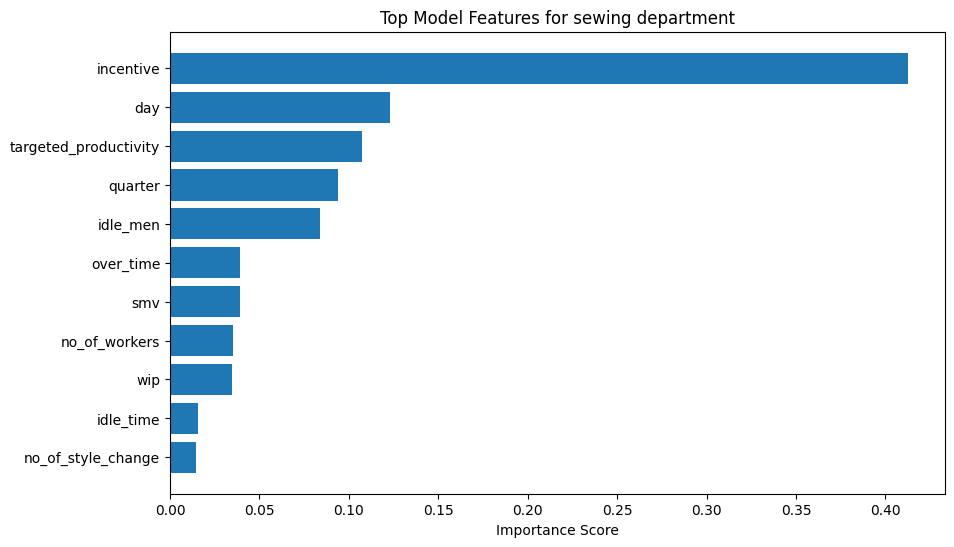

In [288]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Filter and Prepare Data for Cluster 0
X_train_c0 = X_train_final[X_train_final['cluster'] == 0].drop(columns=['cluster','department'])
y_train_c0 = y_train[X_train_final['cluster'] == 0]

numerical_cols_c0 = X_train_c0.select_dtypes(include=np.number).columns.tolist()
categorical_cols_c0 = X_train_c0.select_dtypes(include='object').columns.tolist()

# 2. Preprocessing Pipeline
preprocessor_c0 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_c0),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_c0)
    ])

# 3. XGBoost Model & Parameter Definitions
xgb_config_c0 = {
    "model": XGBRegressor(random_state=42, eval_metric='rmse'),
    "params": {
        'regressor__n_estimators': [100, 200],
        'regressor__learning_rate': [0.01, 0.05, 0.1],
        'regressor__max_depth': [3, 5],
        'regressor__subsample': [0.7, 0.8]
    }
}

# 4. Fit Model with GridSearchCV
pipeline_xgb_c0 = Pipeline(steps=[('preprocessor', preprocessor_c0), ('regressor', xgb_config_c0["model"])])
grid_search_xgb_c0 = GridSearchCV(pipeline_xgb_c0, xgb_config_c0["params"], cv=5, scoring='r2', n_jobs=-1)
grid_search_xgb_c0.fit(X_train_c0, y_train_c0)

xgb_c0 = grid_search_xgb_c0.best_estimator_

# 5. Extract and Aggregate Feature Importance
# Get the raw importances from the regressor
importances = xgb_c0.named_steps['regressor'].feature_importances_

# Get the feature names produced by the preprocessor (e.g., 'cat__day_Wednesday')
feature_names_out = xgb_c0.named_steps['preprocessor'].get_feature_names_out()

# Create a mapping back to the original column names
original_feature_map = []
for name in feature_names_out:
    if name.startswith('num__'):
        # For numerical columns, just remove the 'num__' prefix
        original_feature_map.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        # For categorical columns, find which original column the encoded feature belongs to
        clean_name = name.replace('cat__', '')
        # Check against our list of categorical columns
        for col in categorical_cols_c0:
            if clean_name.startswith(col):
                original_feature_map.append(col)
                break

# 6. Create a DataFrame and Group by Original Feature
df_raw = pd.DataFrame({
    'Original_Feature': original_feature_map,
    'Importance': importances
})

# Sum the importance of all categories belonging to the same original feature
feature_importance_df = df_raw.groupby('Original_Feature')['Importance'].sum().reset_index()
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 7. Print and Visualize
print("### Aggregated XGBoost Feature Importances for Cluster 0 ###")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Original_Feature'].head(15), feature_importance_df['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title('Top Model Features for sewing department')
plt.xlabel('Importance Score')
plt.show()

### Aggregated Random Forest Feature Importances for Cluster 1 ###
         Original_Feature  Importance
5           no_of_workers    0.280320
8                     smv    0.202999
10                    wip    0.180508
7                 quarter    0.113171
9   targeted_productivity    0.092539
0                     day    0.082452
6               over_time    0.048011
2               idle_time    0.000000
1                idle_men    0.000000
3               incentive    0.000000
4      no_of_style_change    0.000000


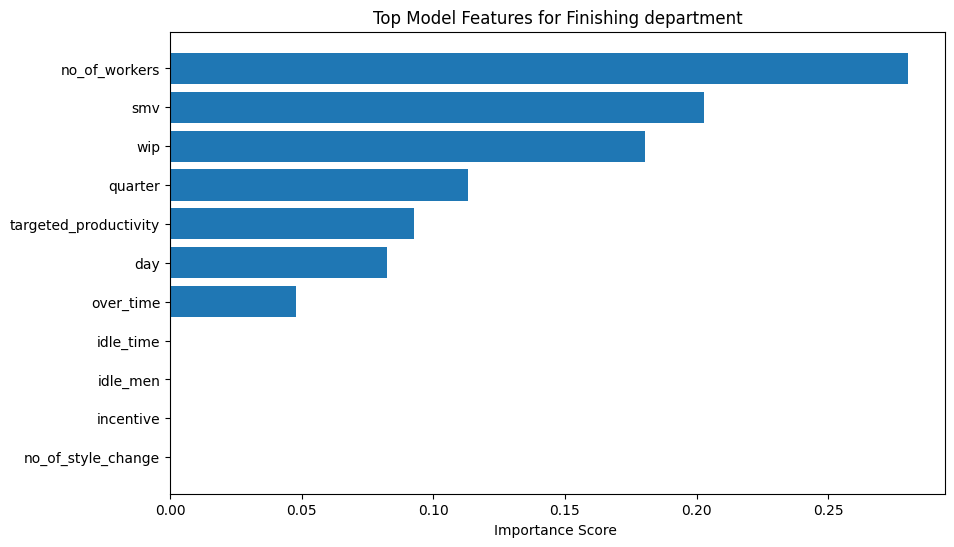

In [289]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Filter data for Cluster 1
X_train_c1 = X_train_final[X_train_final['cluster'] == 1].drop(columns=['cluster','department'])
y_train_c1 = y_train[X_train_final['cluster'] == 1]

# Identify numerical and categorical columns
numerical_cols_c1 = X_train_c1.select_dtypes(include=np.number).columns.tolist()
categorical_cols_c1 = X_train_c1.select_dtypes(include='object').columns.tolist()

# 2. Preprocessing Pipeline
preprocessor_c1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols_c1),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_c1)
    ])

# 3. Random Forest Config (Best params)
rf_config_c1 = {
    "model": RandomForestRegressor(random_state=42),
    "params": {
        'regressor__n_estimators': [200],
        'regressor__max_depth': [8],
        'regressor__min_samples_leaf': [5]
    }
}

# 4. Fit Model
pipeline_rf_c1 = Pipeline(steps=[('preprocessor', preprocessor_c1), ('regressor', rf_config_c1["model"])])
grid_search_rf_c1 = GridSearchCV(pipeline_rf_c1, rf_config_c1["params"], cv=5, scoring='r2', n_jobs=-1)
grid_search_rf_c1.fit(X_train_c1, y_train_c1)

rf_c1 = grid_search_rf_c1.best_estimator_

# 5. Get Importances and Feature Names
importances_rf_c1 = rf_c1.named_steps['regressor'].feature_importances_
feature_names_out_rf_c1 = rf_c1.named_steps['preprocessor'].get_feature_names_out()

# 6. Map Encoded Features back to Original Column Names
original_feature_map = []
for name in feature_names_out_rf_c1:
    if name.startswith('num__'):
        # For numerical features, just strip the prefix
        original_feature_map.append(name.replace('num__', ''))
    elif name.startswith('cat__'):
        # For categorical features, find which original column it belongs to
        clean_name = name.replace('cat__', '')
        for col in categorical_cols_c1:
            if clean_name.startswith(col):
                original_feature_map.append(col)
                break

# 7. Create DataFrame and Aggregate (Sum) by Original Feature
df_raw = pd.DataFrame({
    'Original_Feature': original_feature_map,
    'Importance': importances_rf_c1
})

# Summing importances of categories belonging to the same original variable
feature_importance_df_rf_c1 = df_raw.groupby('Original_Feature')['Importance'].sum().reset_index()
feature_importance_df_rf_c1 = feature_importance_df_rf_c1.sort_values(by='Importance', ascending=False)

# 8. Output and Visualization
print("### Aggregated Random Forest Feature Importances for Cluster 1 ###")
print(feature_importance_df_rf_c1)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_rf_c1['Original_Feature'].head(15), feature_importance_df_rf_c1['Importance'].head(15))
plt.gca().invert_yaxis()
plt.title('Top Model Features for Finishing department')
plt.xlabel('Importance Score ')
plt.show()

#Partial Dependency

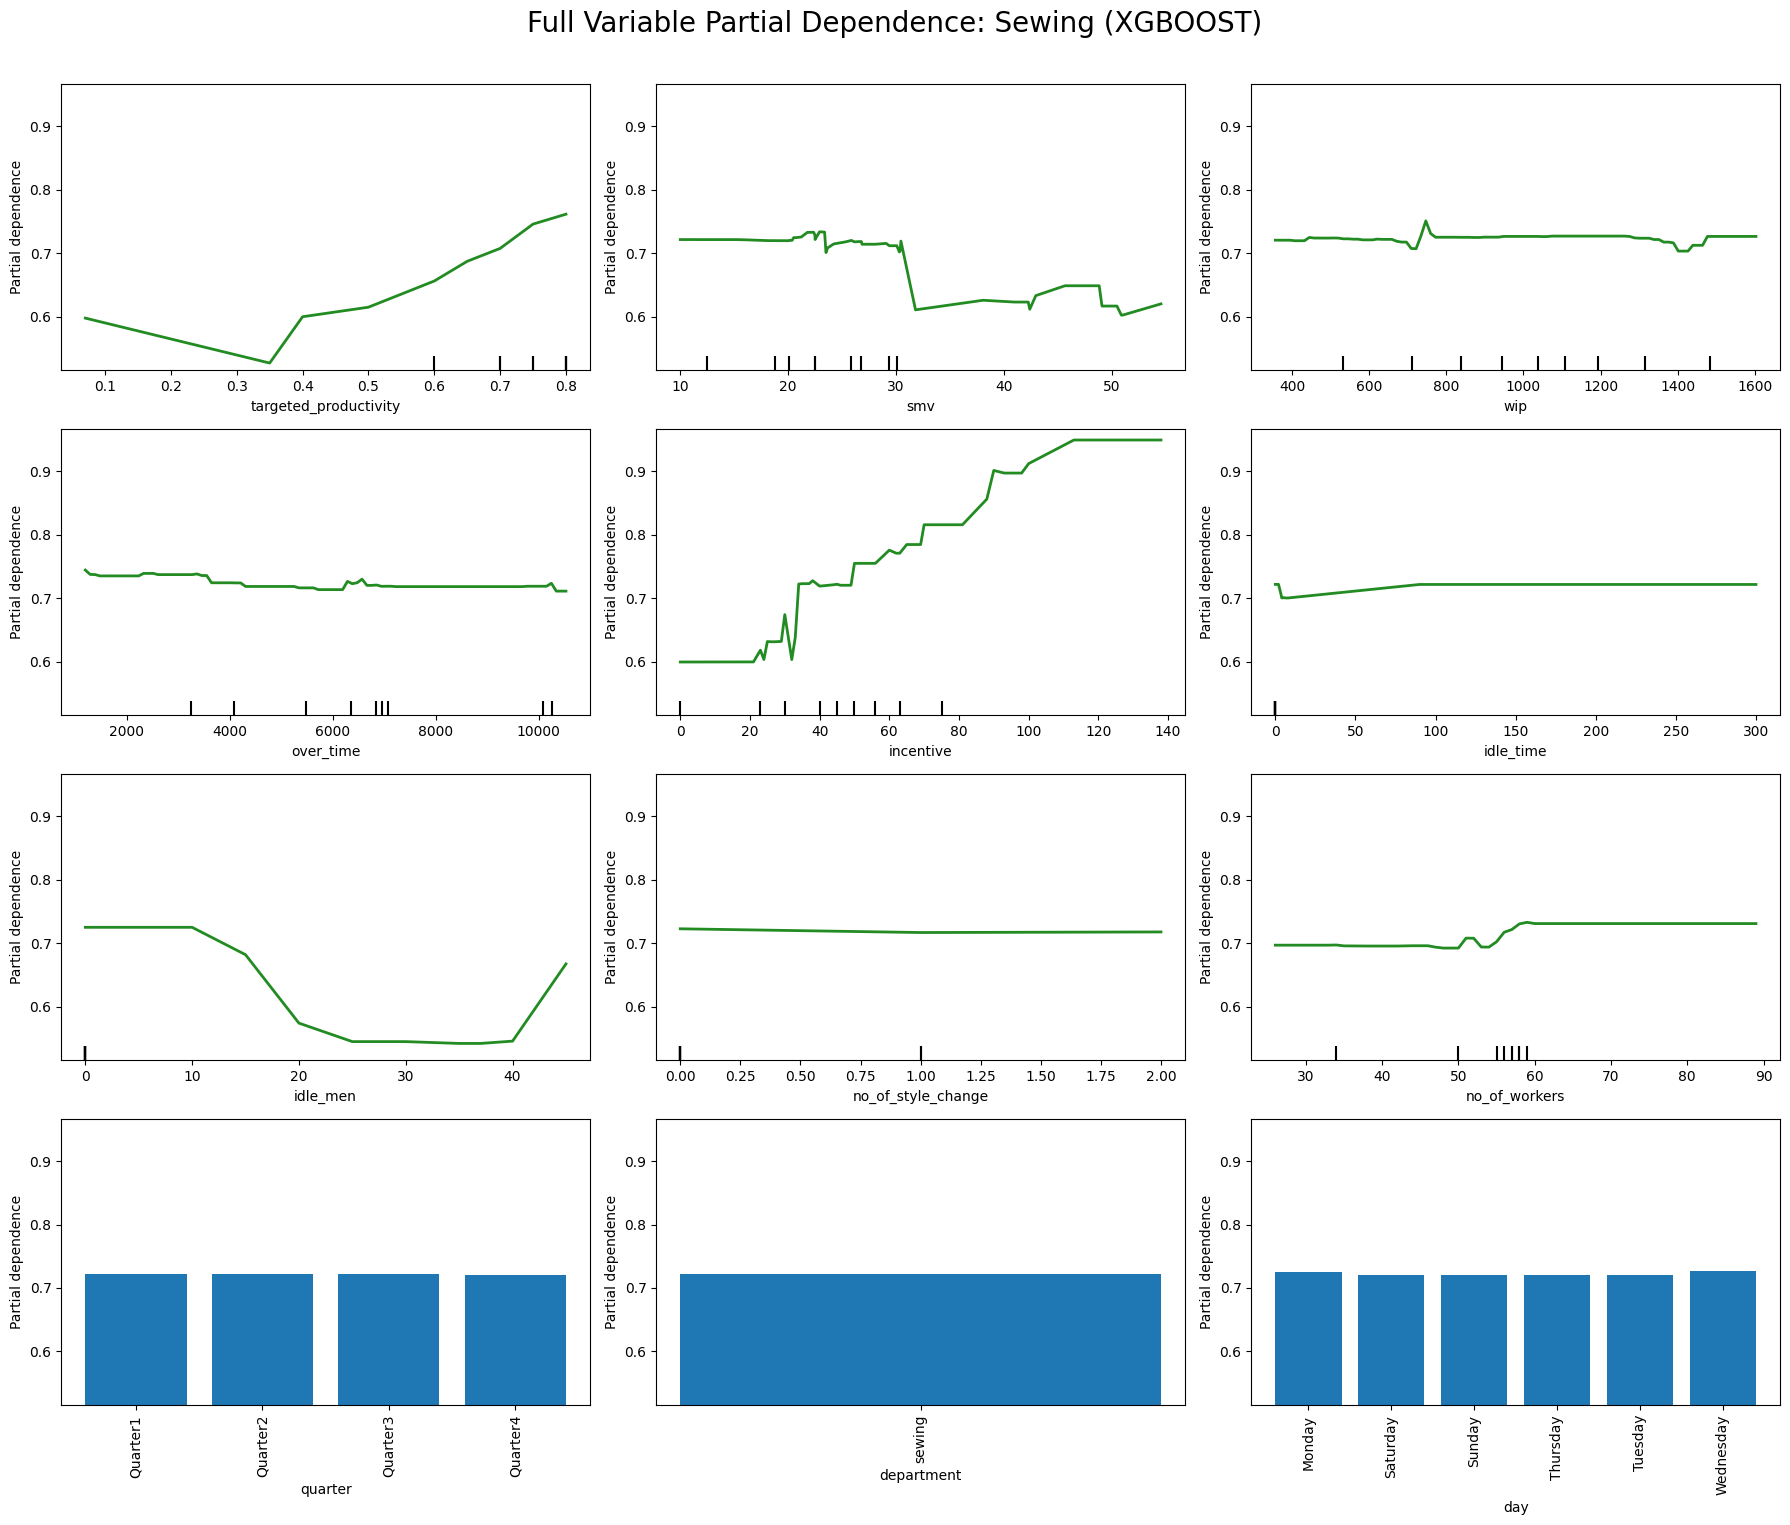

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


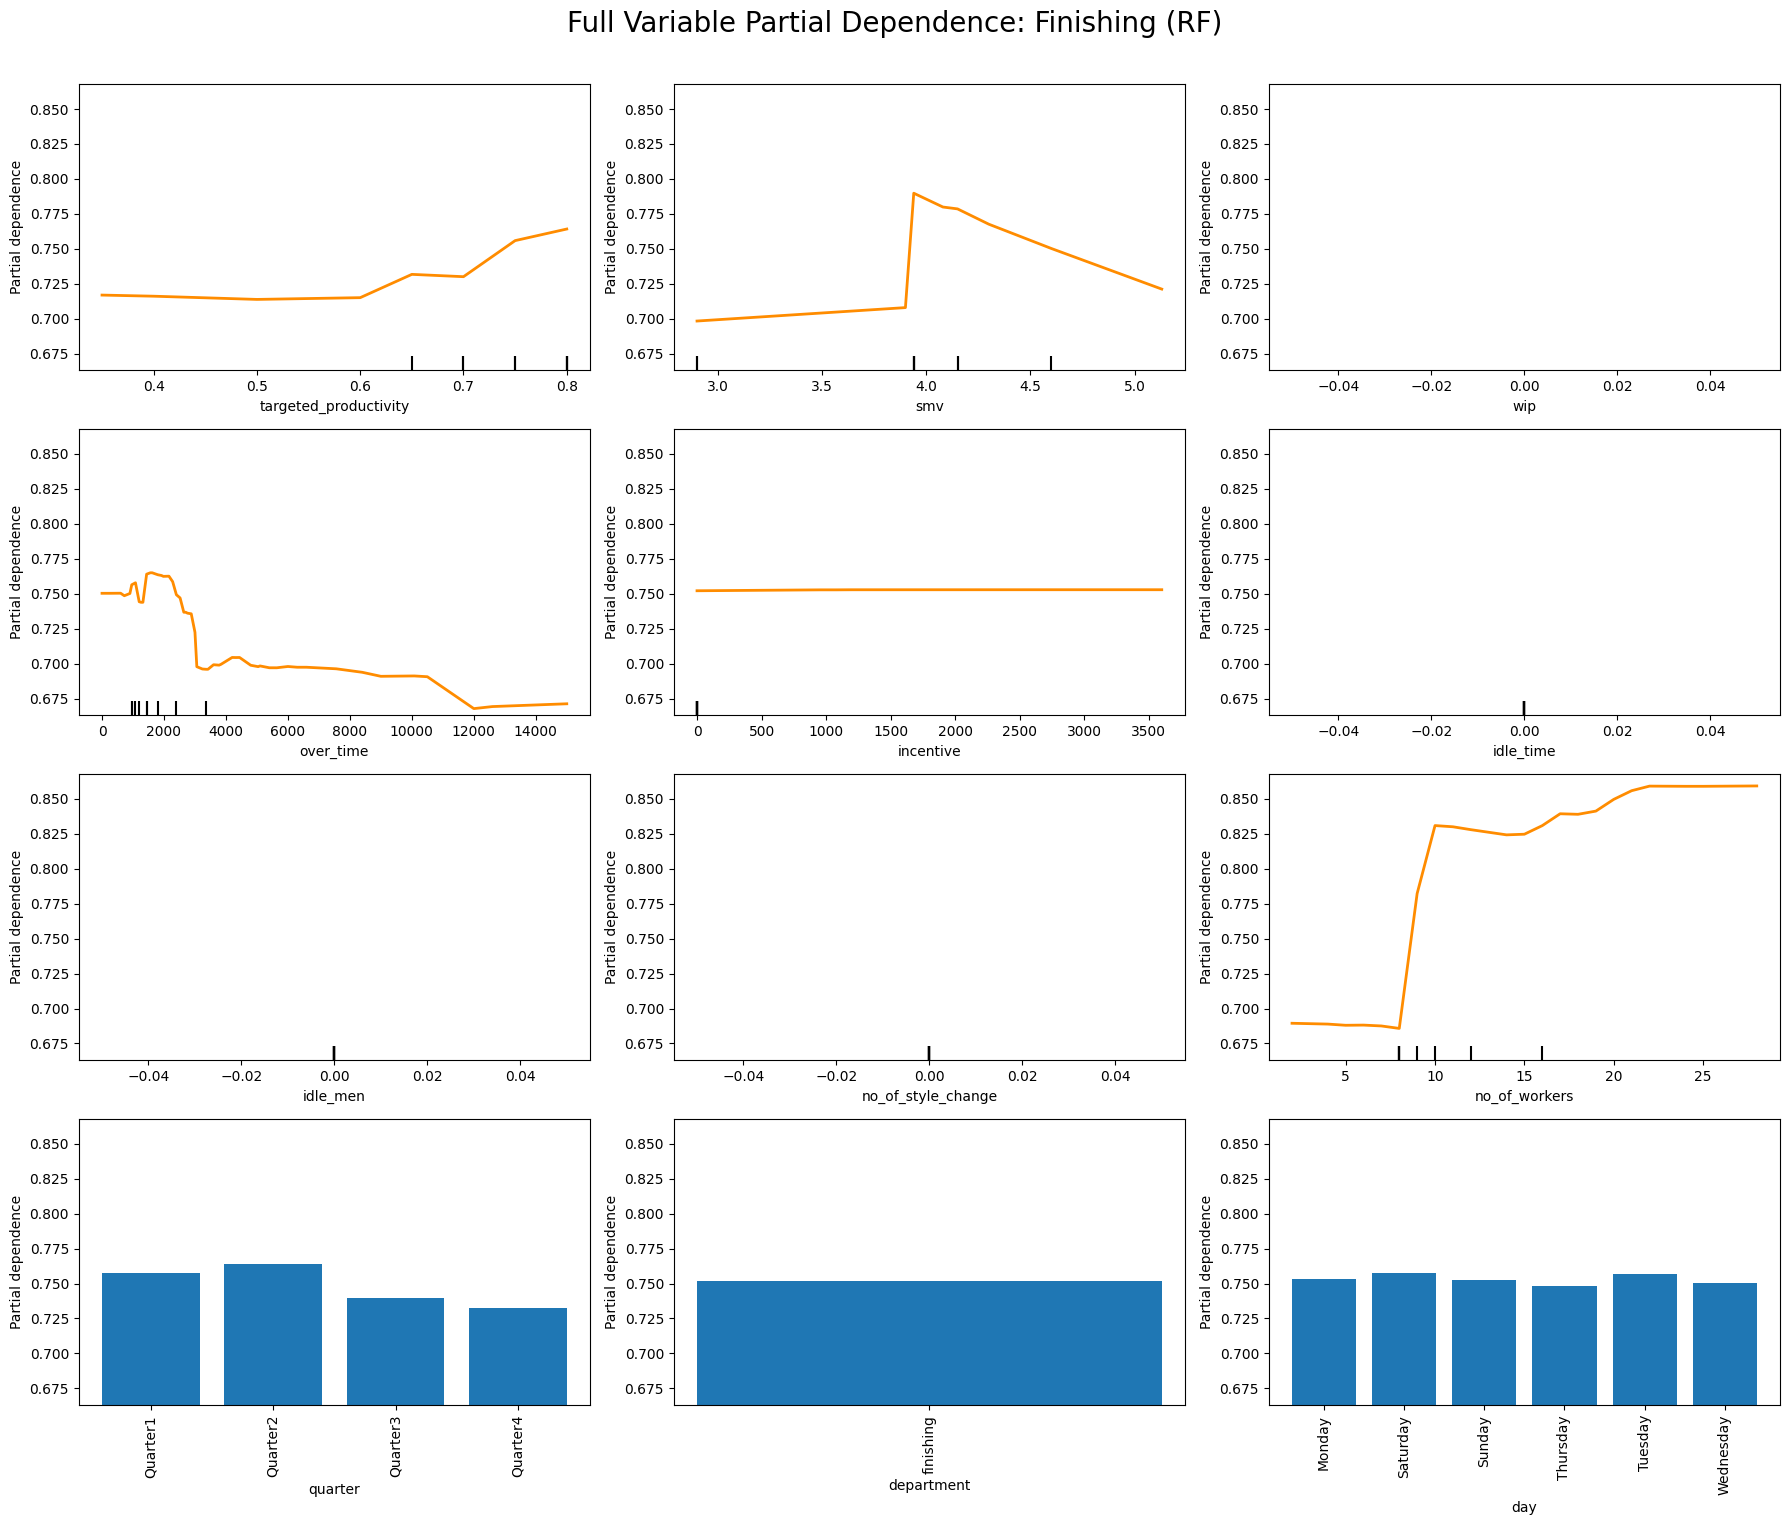

In [286]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def plot_all_variables_pdp(df, dept_name, model_type="xgboost"):
    # 1. Prepare data for the specific department
    dept_df = df[df['department'] == dept_name].copy()

    # Define Target and Features (Using ALL columns except productivity and cluster labels)
    X = dept_df.drop(columns=['actual_productivity', 'cluster'], errors='ignore')
    y = dept_df['actual_productivity']

    # 2. Identify all numerical and categorical columns
    num_cols = X.select_dtypes(include=['number']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()

    # 3. Create the preprocessing pipeline
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ])

    # 4. Initialize and fit the specific model
    if model_type == "xgboost":
        # Best for Sewing
        model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=42)
        color = '#228B22' # Green theme
    else:
        # Best for Finishing
        model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
        color = '#FF8C00' # Orange theme

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X, y)

    # 5. Determine grid size for 'all variables'
    # We will plot all numeric variables and the main categorical ones
    all_features = num_cols + cat_cols
    n_features = len(all_features)
    ncols = 3
    nrows = (n_features // ncols) + (1 if n_features % ncols != 0 else 0)

    # 6. Generate the plot
    fig, ax = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))

    PartialDependenceDisplay.from_estimator(
        pipeline,
        X,
        features=all_features,
        ax=ax.flatten()[:n_features], # Maps to the number of features
        line_kw={"color": color, "linewidth": 2},
        categorical_features=cat_cols # Explicitly specify categorical features
    )

    # Clean up empty subplots
    for i in range(n_features, nrows * ncols):
        fig.delaxes(ax.flatten()[i])

    plt.suptitle(f"Full Variable Partial Dependence: {dept_name.capitalize()} ({model_type.upper()})", fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    plt.show()

# --- EXECUTION ---

# 1. Partial Dependence for Sewing (using XGBoost)
plot_all_variables_pdp(df, 'sewing', model_type="xgboost")

# 2. Partial Dependence for Finishing (using Random Forest)
plot_all_variables_pdp(df, 'finishing', model_type="rf")

In [287]:
import joblib

# 1. Save your best regression models (e.g., XGBoost for Sewing, RF for Finishing)
joblib.dump(best_model_c0, 'model_sewing.pkl')
joblib.dump(best_model_c1, 'model_finishing.pkl')

# 2. Save your data transformers (Critical for preprocessing new inputs!)
joblib.dump(famd, 'famd_transformer.pkl')
joblib.dump(kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']